# OE1 — El entorno de portafolio y el agente DRL sobre la BVL

**Tesis:** Aprendizaje por refuerzo profundo aplicado a la Bolsa de Valores de Lima
· Rodrigo Holguín · Asesor: Dr. E. Villanueva

Este notebook muestra **el entorno construido y la primera corrida del agente**.
No entrena nada: lee los artefactos que produjo `scripts/genera_artefactos_oe1.py`
y los grafica. Corre entero en segundos.

---

### ⚠️ Lo primero, porque condiciona cómo leer todo lo demás

Los números del agente **no son hallazgos**. Son el *piloto de D21*: una vista,
una recompensa, un pliegue, tres semillas, y evaluado sobre **validación**.
El tramo de **prueba no se ha tocado nunca** — el registro de configuraciones
marca `con_test = 0` y ese es el argumento que sostiene el Sharpe deflactado de
la evaluación final.

Lo que sí es sólido y se puede defender hoy:

| | |
|---|---|
| **El entorno** | contabilidad exacta, verificada con tests de conservación |
| **Los costos** | medidos por activo, no supuestos: 111 a 323 pbs de ida y vuelta |
| **Los baselines** | corren *dentro* del mismo simulador, con los mismos costos |
| **El protocolo** | walk-forward con embargo, banda nula, contador de configuraciones |

Las decisiones y su porqué viven en `docs/decisiones_pendientes_OE1.txt`.
El resumen escrito de este notebook está en `docs/resultados_entorno_OE1.txt`.

## 0 · Carga de artefactos

Si esta celda falla, falta correr una vez:
`python scripts/genera_artefactos_oe1.py`

In [1]:
import json, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():        # el notebook vive en notebooks/
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))
# Varias piezas del proyecto usan rutas relativas a la raíz (el parquet de R6,
# el registro de configuraciones, los tests). Se trabaja desde ahí.
os.chdir(RAIZ)

ART = RAIZ / "data" / "interim" / "artefactos_oe1"
carga = lambda f: json.loads((ART / f).read_text(encoding="utf-8"))

PANEL  = carga("panel.json")
COSTOS = carga("costos.json")
BASE   = carga("baselines.json")
NULA   = carga("banda_nula.json")
PLIEG  = carga("pliegues.json")
CURVAS = np.load(ART / "curvas.npz", allow_pickle=False)

# El agente está disponible solo si existen SU RESUMEN Y SUS CURVAS. Tenerlo a
# medias (p.ej. tras correr el generador con --sin-agente) rompía el notebook con
# un KeyError críptico en vez de degradar limpiamente.
HAY_AGENTE = (ART / "agente.json").exists() and any(
    k.startswith("agente_") for k in CURVAS.files
)

# Artefactos de la sesion del 18-sep. Se cargan si existen: el notebook tiene
# que abrir aunque solo se haya corrido el generador barato.
ABLA = carga("ablacion_r8.json") if (ART / "ablacion_r8.json").exists() else None
D25  = carga("d25_presupuesto.json") if (ART / "d25_presupuesto.json").exists() else None
D25C = np.load(ART / "d25_curvas.npz", allow_pickle=False) if (ART / "d25_curvas.npz").exists() else None
AGENTE = carga("agente.json")      if HAY_AGENTE else None
EXPLOR = carga("exploracion.json") if (ART / "exploracion.json").exists() else None
REG    = carga("regimenes.json")   if (ART / "regimenes.json").exists() else None

TICKERS = PANEL["tickers"]
CAPITAL = 1_800_000.0

# --- estilo: sobrio, sin rejilla pesada, legible en proyector ---
plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False,
})
C = {"1N": "#2b6cb0", "caja": "#2f855a", "agente": "#c05621",
     "gris": "#a0aec0", "rojo": "#c53030", "morado": "#6b46c1"}
pct = FuncFormatter(lambda v, _: f"{v:.0%}")
# Para rangos chicos: con {:.0%} las marcas de 2.5% y 7.5% se redondean a "2%" y
# "8%" y el eje miente. Un decimal lo arregla sin ensuciar los ejes anchos.
pct1 = FuncFormatter(lambda v, _: f"{v:.1%}")

def curva(clave):
    return CURVAS[clave], pd.to_datetime(CURVAS[clave + "__fechas"])

print(f"artefactos: {ART}")
print(f"panel      : {PANEL['n_fechas']} fechas x {PANEL['n_activos']} activos "
      f"({PANEL['fecha_inicio']} -> {PANEL['fecha_fin']})")
print(f"agente     : {'artefactos presentes' if HAY_AGENTE else 'NO generados (corre el script sin --sin-agente)'}")

artefactos: C:\tesis\data\interim\artefactos_oe1
panel      : 3512 fechas x 7 activos (2012-01-02 -> 2025-12-30)
agente     : artefactos presentes


---
## 1 · Qué es el entorno

Un agente de **portafolio**: observa el cierre y devuelve pesos sobre
**7 activos + caja** (∑ = 1, *long-only*, sin apalancamiento).

**El reloj es lo único que hay que tener claro** (D13). La decisión que se toma
mirando el cierre de `e−1` se **ejecuta al cierre de `e`**, y recién entonces el
portafolio gana el retorno de `e → e+1`. Por construcción no existe forma de que
una decisión use información de su propio día de ejecución.

Las cuatro piezas que hacen que el simulador sea económicamente honesto:

| pieza | decisión | qué hace |
|---|---|---|
| **Acción relativa** | D2 enmendada | la acción *ajusta* los pesos actuales; `a = 0` **es no operar**, y es alcanzable y barato |
| **Máscara dura** | D8 | `is_no_trade` prohíbe operar ("si nadie quiere jugar, no juega"); `is_stale` **no prohíbe: encarece** |
| **Caja remunerada** | D9 | la caja rinde la tasa del BCRP / 365. Si rindiera cero, el entorno castigaría al agente por defenderse |
| **Costo por activo** | D7 | nunca un costo único: el spread va de 8 pbs en Alicorp a 220 en Luz del Sur |

La recompensa primaria es el **Sharpe diferencial** (DSR, Moody-Saffell): da señal
*por paso* en vez de una métrica de fin de episodio, y no tiene λ que calibrar.
Como depende de la historia, sus estadísticos suficientes **se concatenan a la
observación** — sin eso el problema no sería markoviano.

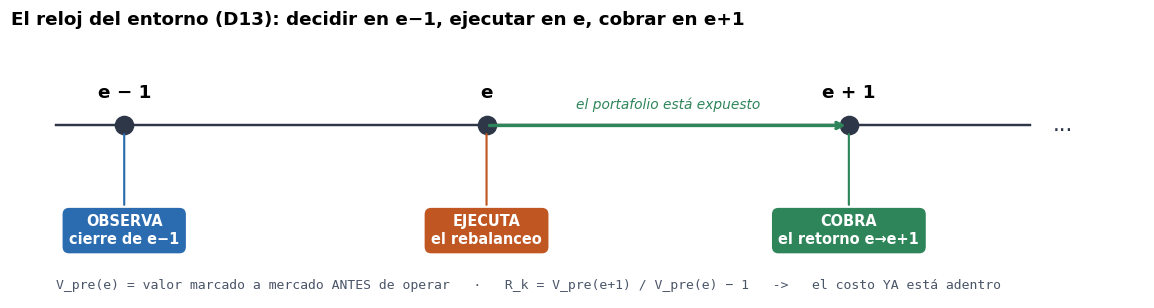

In [2]:
fig, ax = plt.subplots(figsize=(11, 2.9))
ax.axis("off")
xs = [0.10, 0.42, 0.74]
etiq = ["e − 1", "e", "e + 1"]
ax.plot([0.04, 0.90], [0.62, 0.62], color="#2d3748", lw=1.6, zorder=1)
for x, t in zip(xs, etiq):
    ax.scatter([x], [0.62], s=140, color="#2d3748", zorder=3)
    ax.text(x, 0.72, t, ha="center", fontsize=12, fontweight="bold")

cajas = [
    (xs[0], "OBSERVA\ncierre de e−1", C["1N"]),
    (xs[1], "EJECUTA\nel rebalanceo", C["agente"]),
    (xs[2], "COBRA\nel retorno e→e+1", C["caja"]),
]
for x, txt, col in cajas:
    ax.annotate(txt, xy=(x, 0.60), xytext=(x, 0.24), ha="center", va="center",
                fontsize=9.5, color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.45", fc=col, ec="none"),
                arrowprops=dict(arrowstyle="-", color=col, lw=1.4))

ax.annotate("", xy=(xs[2], 0.62), xytext=(xs[1], 0.62),
            arrowprops=dict(arrowstyle="->", color=C["caja"], lw=2.2))
ax.text((xs[1] + xs[2]) / 2, 0.68, "el portafolio está expuesto", ha="center",
        fontsize=9, color=C["caja"], style="italic")
ax.text(0.92, 0.62, "...", fontsize=14, va="center", color="#2d3748")
ax.text(0.04, 0.03,
        "V_pre(e) = valor marcado a mercado ANTES de operar   ·   "
        "R_k = V_pre(e+1) / V_pre(e) − 1   ->   el costo YA está adentro",
        fontsize=8.6, color="#4a5568", family="monospace")
ax.set_title("El reloj del entorno (D13): decidir en e−1, ejecutar en e, cobrar en e+1", loc="left")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.95)
plt.tight_layout(); plt.show()

---
## 2 · El panel que consume el entorno

Salida de R6 (OE2), ya limpio, causal y alineado. OE1 **no re-reconcilia datos**:
les da forma (normalización causal por activo, winsorización, calentamiento).

In [3]:
resumen = pd.Series({
    "fechas del panel":            f"{PANEL['n_fechas']:,}",
    "activos":                     PANEL["n_activos"],
    "horizonte":                   f"{PANEL['fecha_inicio']} → {PANEL['fecha_fin']}",
    "primer día con los 7 listados": PANEL["primer_dia_con_los_7"] + "  (IPO de InRetail)",
    "primer día OPERABLE":         PANEL["primer_dia_operable"] + f"  (tras {PANEL['warmup_D6']}d de calentamiento D6)",
    "features por activo (vista solo_mercado)": PANEL["features_por_activo"],
    "dimensión de la observación": f"{PANEL['dim_observacion']}  = 7×{PANEL['features_por_activo']} + 8 pesos + 2 del DSR",
    "tasa BCRP media (anual)":     f"{PANEL['tasa_ref_anual_media_pct']:.2f}%  (rango {PANEL['tasa_ref_anual_min_pct']:.2f}–{PANEL['tasa_ref_anual_max_pct']:.2f}%)",
}, name="")
display(resumen.to_frame())

print("\nCuánto crece la observación con cada vista de la ablación de R8:")
display(pd.DataFrame([
    {"vista": v, "features/activo": d["features_por_activo"], "dim. observación": d["dim_observacion"]}
    for v, d in PANEL["vistas"].items()
]).set_index("vista"))

,
fechas del panel,"3,512"
activos,7
horizonte,2012-01-02 → 2025-12-30
primer día con los 7 listados,2012-10-05 (IPO de InRetail)
primer día OPERABLE,2013-01-02 (tras 250d de calentamiento D6)
features por activo (vista solo_mercado),11
dimensión de la observación,87 = 7×11 + 8 pesos + 2 del DSR
tasa BCRP media (anual),3.84% (rango 0.25–7.75%)



Cuánto crece la observación con cada vista de la ablación de R8:


,features/activo,dim. observación
vista,,
solo_mercado,11,87
mercado_macro,18,136
mercado_sentimiento,24,178
mercado_fundamentales,33,241
completa,53,381


### 2.1 · `is_no_trade` y `is_stale` NO son lo mismo

Se confunden con facilidad y significan cosas opuestas en el simulador:

* **`is_no_trade`** → *prohibición dura*. El activo conserva su peso y el agente
  reparte solo el presupuesto remanente. Casi no ocurre (InRetail 5.5%, el resto ~0%).
* **`is_stale`** → el precio viene **arrastrado** de un día anterior. **No prohíbe:
  encarece** (recargo en el modelo de costos). Y ocurre muchísimo: entre 2.5% y
  43.5% de los días según el activo.

Esa asimetría es la que impide que el entorno regale liquidez que la BVL no tiene.

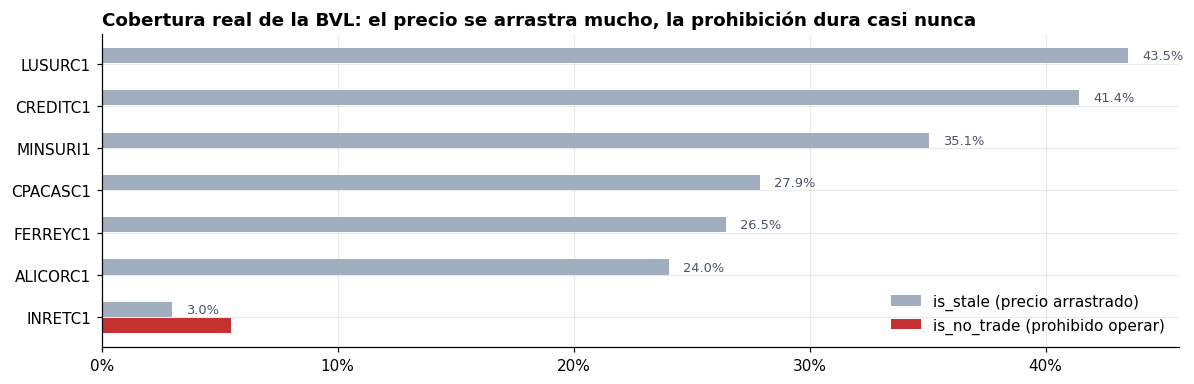

días en que los 7 activos son operables      : 94.5%
días en que los 7 tienen precio PROPIO       : 10.1%


In [4]:
cob = pd.DataFrame({
    "is_stale (precio arrastrado)": pd.Series(PANEL["frac_stale"]),
    "is_no_trade (prohibido operar)": pd.Series(PANEL["frac_no_trade"]),
}).loc[TICKERS].sort_values("is_stale (precio arrastrado)")

fig, ax = plt.subplots(figsize=(11, 3.6))
y = np.arange(len(cob))
ax.barh(y + 0.19, cob.iloc[:, 0], height=0.36, color=C["gris"], label=cob.columns[0])
ax.barh(y - 0.19, cob.iloc[:, 1], height=0.36, color=C["rojo"], label=cob.columns[1])
ax.set_yticks(y); ax.set_yticklabels(cob.index)
ax.xaxis.set_major_formatter(pct)
for i, v in enumerate(cob.iloc[:, 0]):
    ax.text(v + 0.006, i + 0.19, f"{v:.1%}", va="center", fontsize=8.5, color="#4a5568")
ax.set_title("Cobertura real de la BVL: el precio se arrastra mucho, la prohibición dura casi nunca", loc="left")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"días en que los 7 activos son operables      : {PANEL['frac_dias_los_7_operables']:.1%}")
print(f"días en que los 7 tienen precio PROPIO       : {PANEL['frac_dias_los_7_con_precio_propio']:.1%}")

### 2.2 · Las siete series contra la caja

El gráfico que más conversación produce: en 2013-2025, **la caja al BCRP le gana
a la renta variable de este universo**. No es una opinión sobre la BVL — es lo que
hay en el panel, y es la razón por la que D9 (caja remunerada) no era un detalle
contable sino una decisión que cambia el problema.

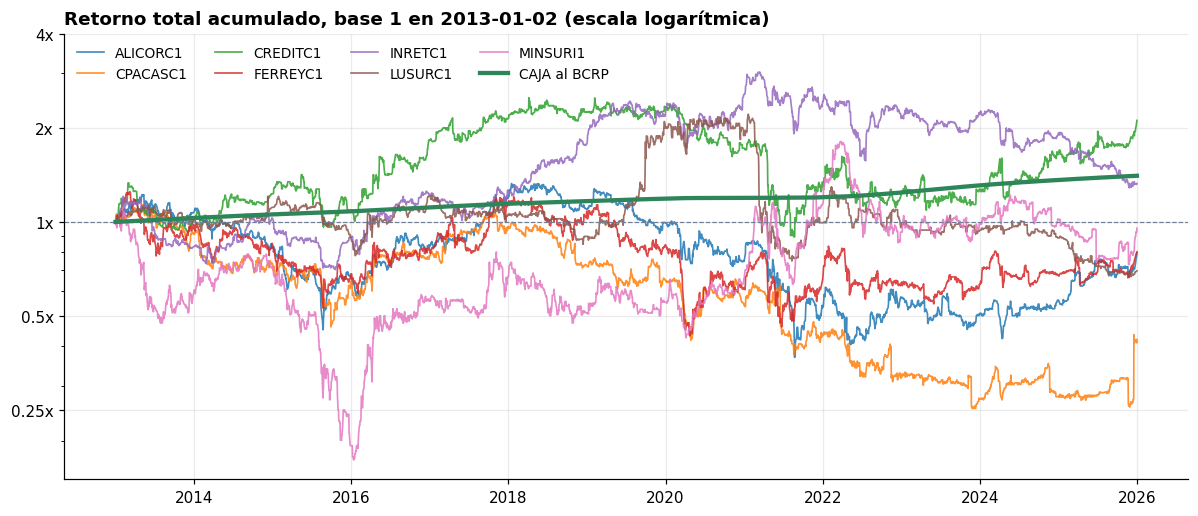

,retorno total 2013-2025
CPACASC1,-57.9%
LUSURC1,-30.2%
ALICORC1,-20.3%
FERREYC1,-19.7%
MINSURI1,-4.5%
INRETC1,32.8%
CREDITC1,111.2%
CAJA (BCRP),40.5%


In [5]:
from src.env import load_panel

p = load_panel(view="solo_mercado", warmup=250)
i0 = PANEL["primer_indice_operable"]
fechas = pd.to_datetime(p.dates[i0:])
precios = p.prices[i0:] / p.prices[i0]
caja = np.cumprod(1.0 + p.rf_daily[i0:])

fig, ax = plt.subplots(figsize=(11, 4.8))
for j, t in enumerate(p.tickers):
    ax.plot(fechas, precios[:, j], lw=1.1, alpha=0.85, label=t)
ax.plot(fechas, caja, lw=2.8, color=C["caja"], label="CAJA al BCRP", zorder=5)
ax.axhline(1.0, color="#718096", lw=0.8, ls="--")
ax.set_yscale("log")
ax.set_yticks([0.25, 0.5, 1, 2, 4]); ax.set_yticklabels(["0.25x", "0.5x", "1x", "2x", "4x"])
ax.set_title("Retorno total acumulado, base 1 en 2013-01-02 (escala logarítmica)", loc="left")
ax.legend(ncol=4, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

final = pd.Series(precios[-1] - 1, index=p.tickers).sort_values()
final["CAJA (BCRP)"] = caja[-1] - 1
display(final.to_frame("retorno total 2013-2025").style.format("{:.1%}"))

**Los dos saltos verticales son reales, no errores de datos.** Se verificaron
uno por uno; son los **únicos** movimientos diarios mayores a 25% en todo el panel:

| activo | fecha | salto | qué fue |
|---|---|---|---|
| LUSURC1 | 2019-10-01 | **+41.1%** | OPA de China Yangtze |
| LUSURC1 | 2020-04-14 | +24.4% | cierre de la operación |
| LUSURC1 | 2021-03-11/12 | −15.0% y −13.0% | colapso del *float* residual |
| CPACASC1 | 2025-12-17 | **+61.1%** | repricing **persistente** (se mantiene ~7.00 hasta fin de año) |

Dos consecuencias que conviene decir en voz alta:

* La caída de Luz del Sur en 2021 es la contraparte cuantitativa del *"está casi
  muerto"* del especialista: tras la OPA queda un *float* mínimo. El activo se
  queda en el universo por ser historia académica, y sus **323 pbs** son la
  penalidad correspondiente.
* ⚠️ **El salto de Pacasmayo cae dentro del tramo de PRUEBA del pliegue 2**
  (2023-12-22 … 2025-12-31). Un evento de +61% en un día, en un tramo que aún no
  se toca, puede dominar por sí solo el resultado final de ese pliegue.
  **Hay que decidirlo antes de mirar el test** — si se trata como evento normal o
  se declara — porque decidirlo después es elegir el resultado.

---
## 3 · El modelo de costos (D7) — el término dominante, no un detalle

$$\text{costo}_i = \underbrace{\max(S/40,\; 0.43\%\cdot N_i)\cdot(1{+}\text{IGV})}_{\text{comisión SAB}}
+ \underbrace{0.00755\%\cdot N_i}_{\text{BVL+Cavali+SMV}}
+ \underbrace{\tfrac{1}{2}\text{spread}_i\cdot N_i}_{\text{cruzar la punta}}$$

Dos cosas que hay que decir en voz alta:

1. **El spread es por activo y varía un orden de magnitud** (8 pbs en Alicorp,
   220 en Luz del Sur). Un costo único habría escondido exactamente el problema.
2. **La comisión mínima de S/40 crea un piso económico por orden.** Debajo de
   **S/9,302** la tarifa fija domina: mover S/2,000 costaría ~200 pbs sobre lo
   transado. De ahí sale la *banda de no-operación* — y no es un parámetro
   elegido a mano, **se deriva** de `min_fee / comisión`.

> **Pendiente declarado:** las cifras salen de la web de Renta 4 Perú, no del
> tarifario primario, y el spread es **un snapshot del 2026-07-27**, no una serie
> histórica. Un spread constante subestima el costo justo en el estrés (2020-2021),
> que es cuando el agente quiere operar. **Ese es el argumento para ir a Bloomberg**
> (PX_BID / PX_ASK), no "dos vectores de precio".

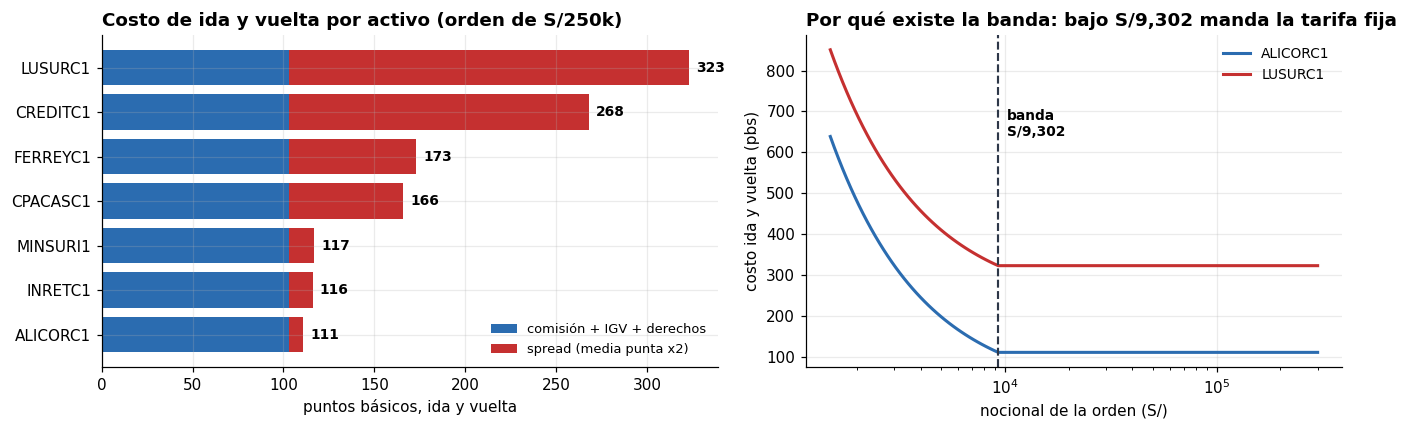

In [6]:
rt = pd.Series(COSTOS["roundtrip_bps_por_nocional"]["250000"]).loc[TICKERS].sort_values()
spr = pd.Series(COSTOS["spread_snapshot_ida_vuelta_bps"]).loc[rt.index]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.0), gridspec_kw={"width_ratios": [1.15, 1]})

y = np.arange(len(rt))
a1.barh(y, rt - spr, color=C["1N"], label="comisión + IGV + derechos")
a1.barh(y, spr, left=rt - spr, color=C["rojo"], label="spread (media punta x2)")
a1.set_yticks(y); a1.set_yticklabels(rt.index)
for i, v in enumerate(rt):
    a1.text(v + 4, i, f"{v:.0f}", va="center", fontsize=9, fontweight="bold")
a1.set_xlabel("puntos básicos, ida y vuelta")
a1.set_title("Costo de ida y vuelta por activo (orden de S/250k)", loc="left")
a1.legend(loc="lower right", fontsize=8.5)

nocionales = np.logspace(np.log10(1500), np.log10(300_000), 120)
banda = COSTOS["banda_no_operacion_pen"]
com, mini, igv = COSTOS["comision_pct"], COSTOS["comision_minima_pen"], COSTOS["igv"]
for t, col in [("ALICORC1", C["1N"]), ("LUSURC1", C["rojo"])]:
    media_punta = COSTOS["spread_snapshot_ida_vuelta_bps"][t] / 2 / 10_000
    c = (np.maximum(mini, com * nocionales) * (1 + igv)
         + COSTOS["derechos_mercado"] * nocionales + media_punta * nocionales)
    a2.plot(nocionales, 2 * c / nocionales * 1e4, lw=2, color=col, label=t)
a2.axvline(banda, color="#2d3748", ls="--", lw=1.4)
a2.text(banda * 1.1, a2.get_ylim()[1] * 0.72, f"banda\nS/{banda:,.0f}", fontsize=9, fontweight="bold")
a2.set_xscale("log"); a2.set_xlabel("nocional de la orden (S/)")
a2.set_ylabel("costo ida y vuelta (pbs)")
a2.set_title("Por qué existe la banda: bajo S/9,302 manda la tarifa fija", loc="left")
a2.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 4 · Los baselines, dentro del mismo simulador

Decisión de diseño y **no es cosmética**: las políticas de referencia **no se
calculan aparte con pandas**. Corren en el mismo entorno, con el mismo modelo de
costos, la misma máscara y la misma caja remunerada. Así la comparación es exacta
*por construcción* y no por revisión.

*(El especialista de mercado advirtió que el 1/N es "casi invencible" si no hay
costos; por eso cada baseline corre con **su propia frecuencia de rebalanceo** —
compararse contra un 1/N rebalanceado a diario bajo 0.43% sería ganarle a un rival
mal implementado.)*

In [7]:
ORDEN = ["1/N diario sin costo", "1/N diario", "1/N semanal", "1/N mensual",
         "1/N trimestral", "comprar y mantener", "solo caja",
         "markowitz tangencia", "markowitz tangencia-LW", "markowitz min-var"]
ORDEN = [k for k in ORDEN if k in BASE["horizonte_completo"]]
tab = pd.DataFrame(BASE["horizonte_completo"]).T.loc[ORDEN]
tab = tab[["retorno_total", "retorno_anualizado", "sharpe", "sortino",
           "max_drawdown", "rotacion_anual", "costo_total"]]
tab.columns = ["ret. total", "ret. anual", "sharpe", "sortino",
               "máx. drawdown", "rotación/año", "costo S/"]
display(tab.style.format({"ret. total": "{:.1%}", "ret. anual": "{:.1%}",
                          "sharpe": "{:.2f}", "sortino": "{:.2f}",
                          "máx. drawdown": "{:.1%}", "rotación/año": "{:.2f}",
                          "costo S/": "{:,.0f}"}))

c_sin = BASE["horizonte_completo"]["1/N diario sin costo"]["retorno_total"]
c_con = BASE["horizonte_completo"]["1/N diario"]["retorno_total"]
peaje = BASE["horizonte_completo"]["1/N diario"]["costo_total"]
print(f"\nEL COSTO SE COME {100*(c_sin - c_con):.0f} PUNTOS: el 1/N diario pasa de "
      f"{c_sin:.1%} a {c_con:.1%}.")
print(f"S/{peaje:,.0f} sobre S/{CAPITAL:,.0f} = {peaje/CAPITAL:.0%} del capital inicial en peaje, en 13 años.")

,ret. total,ret. anual,sharpe,sortino,máx. drawdown,rotación/año,costo S/
1/N diario sin costo,32.8%,2.2%,0.05,0.06,-44.9%,2.50,0
1/N diario,8.5%,0.6%,-0.06,-0.08,-46.4%,1.17,"355,331"
1/N semanal,15.1%,1.1%,-0.03,-0.04,-45.6%,0.88,"232,113"
1/N mensual,17.2%,1.2%,-0.02,-0.03,-45.5%,0.56,"131,683"
1/N trimestral,21.0%,1.5%,-0.00,-0.00,-45.0%,0.38,"86,857"
comprar y mantener,0.7%,0.1%,-0.11,-0.15,-44.2%,0.08,"16,230"
solo caja,40.5%,2.7%,0.00,0.00,0.0%,0.00,0
markowitz tangencia,14.8%,1.1%,0.04,0.05,-55.1%,5.37,"1,175,776"
markowitz tangencia-LW,31.0%,2.1%,0.08,0.12,-53.9%,5.18,"1,209,164"
markowitz min-var,-11.7%,-1.0%,-0.18,-0.25,-50.5%,1.75,"427,460"



EL COSTO SE COME 24 PUNTOS: el 1/N diario pasa de 32.8% a 8.5%.
S/355,331 sobre S/1,800,000 = 20% del capital inicial en peaje, en 13 años.


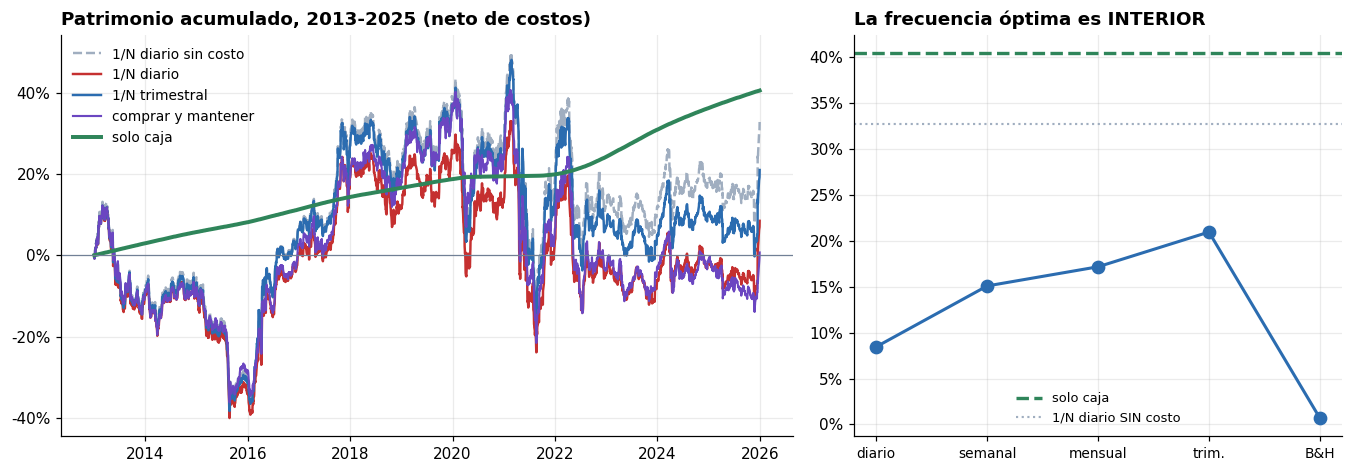

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})

estilos = [("1/N diario sin costo", C["gris"], "--", 1.6),
           ("1/N diario", C["rojo"], "-", 1.6),
           ("1/N trimestral", C["1N"], "-", 1.6),
           ("comprar y mantener", C["morado"], "-", 1.4),
           ("solo caja", C["caja"], "-", 2.6)]
for etiqueta, col, ls, lw in estilos:
    eq, fe = curva("completo__" + etiqueta)
    a1.plot(fe, eq / eq[0] - 1, color=col, ls=ls, lw=lw, label=etiqueta)
a1.axhline(0, color="#718096", lw=0.8)
a1.yaxis.set_major_formatter(pct)
a1.set_title("Patrimonio acumulado, 2013-2025 (neto de costos)", loc="left")
a1.legend(fontsize=9, loc="upper left")

frec = ["1/N diario", "1/N semanal", "1/N mensual", "1/N trimestral", "comprar y mantener"]
rets = [BASE["horizonte_completo"][f]["retorno_total"] for f in frec]
a2.plot(range(len(frec)), rets, "o-", color=C["1N"], lw=2, ms=8)
a2.axhline(BASE["horizonte_completo"]["solo caja"]["retorno_total"],
           color=C["caja"], lw=2.2, ls="--", label="solo caja")
a2.axhline(c_sin, color=C["gris"], lw=1.4, ls=":", label="1/N diario SIN costo")
a2.set_xticks(range(len(frec)))
a2.set_xticklabels(["diario", "semanal", "mensual", "trim.", "B&H"], fontsize=9)
a2.yaxis.set_major_formatter(pct)
a2.set_title("La frecuencia óptima es INTERIOR", loc="left")
a2.legend(fontsize=8.5, loc="lower center")
plt.tight_layout(); plt.show()

**Cuatro lecturas, y ninguna es cosmética.** *Las cifras las imprime la celda de
abajo leyendo los artefactos, no están escritas a mano: la corrección de fecha
del 12-sep cambió todos estos números y una versión anterior de este notebook
quedó con los viejos en la prosa mientras la tabla ya mostraba los nuevos.*

1. **El costo se come más de veinte puntos de retorno.** El aguijón deja de ser
   una advertencia y pasa a ser una medición.

2. **La frecuencia óptima es INTERIOR**, y eso contesta con datos la pregunta
   del especialista: rebalancear más seguido no es mejor, pero no rebalancear
   tampoco. Sí hay prima por rebalancear, y el costo se la come entera si se
   hace a diario. *Su predicción pre-registrada (horizonte largo, baja
   rotación) ya se cumple para los baselines.*

3. **La caja le gana a todo**, con drawdown 0% contra −45%. **La vara del
   agente no es el 1/N: es "¿le gana a estar en el banco?"**

4. **Markowitz no es un rival de paja, y tampoco un campeón** (D26). La
   media-varianza clásica con ventana móvil de 252 días le gana al 1/N diario y
   pierde contra el 1/N trimestral, con el peor drawdown de la tabla. Y cuando
   ningún activo supera a la tasa libre de riesgo, la tangente long-only **no
   existe** y la regla pre-registrada la manda a caja: o sea la teoría clásica
   también recomienda salirse del mercado en este universo.

In [9]:
H = BASE["horizonte_completo"]
c_sin = H["1/N diario sin costo"]["retorno_total"]
c_con = H["1/N diario"]["retorno_total"]
frecs = ["1/N diario", "1/N semanal", "1/N mensual", "1/N trimestral", "comprar y mantener"]
mejor_rv = max(frecs, key=lambda k: H[k]["retorno_total"])

print(f"1. EL COSTO SE COME {100*(c_sin-c_con):.0f} PUNTOS: {c_sin:.1%} -> {c_con:.1%}, "
      f"S/{H['1/N diario']['costo_total']:,.0f} = {H['1/N diario']['costo_total']/CAPITAL:.0%} "
      f"del capital inicial en peaje, en 13 años.")
print("2. FRECUENCIA: " + " < ".join(
    f"{k.replace('1/N ','')} {H[k]['retorno_total']:.1%}"
    for k in sorted(frecs, key=lambda k: H[k]['retorno_total'])))
print(f"3. LA CAJA: {H['solo caja']['retorno_total']:.1%} contra "
      f"{H[mejor_rv]['retorno_total']:.1%} del mejor baseline de renta variable "
      f"({mejor_rv}), con drawdown {H['solo caja']['max_drawdown']:.1%} contra "
      f"{H[mejor_rv]['max_drawdown']:.1%}.")
for k in [k for k in H if k.startswith("markowitz")]:
    deg = (f" · degeneró a caja {H[k]['veces_degenerado']}/{H[k]['veces_optimizado']} "
           f"({H[k]['veces_degenerado']/H[k]['veces_optimizado']:.0%} del horizonte)"
           if "veces_degenerado" in H[k] else "")
    print(f"4. {k}: ret {H[k]['retorno_total']:.1%} · sharpe {H[k]['sharpe']:.2f} · "
          f"sortino {H[k]['sortino']:.2f} · maxDD {H[k]['max_drawdown']:.1%} · "
          f"rot {H[k]['rotacion_anual']:.2f}{deg}")

1. EL COSTO SE COME 24 PUNTOS: 32.8% -> 8.5%, S/355,331 = 20% del capital inicial en peaje, en 13 años.
2. FRECUENCIA: comprar y mantener 0.7% < diario 8.5% < semanal 15.1% < mensual 17.2% < trimestral 21.0%
3. LA CAJA: 40.5% contra 21.0% del mejor baseline de renta variable (1/N trimestral), con drawdown 0.0% contra -45.0%.
4. markowitz tangencia: ret 14.8% · sharpe 0.04 · sortino 0.05 · maxDD -55.1% · rot 5.37 · degeneró a caja 12/156 (8% del horizonte)
4. markowitz tangencia-LW: ret 31.0% · sharpe 0.08 · sortino 0.12 · maxDD -53.9% · rot 5.18 · degeneró a caja 12/156 (8% del horizonte)
4. markowitz min-var: ret -11.7% · sharpe -0.18 · sortino -0.25 · maxDD -50.5% · rot 1.75 · degeneró a caja 0/156 (0% del horizonte)


---
## 5 · La banda nula (D10) — qué consigue el azar

200 carteras Dirichlet con **las mismas restricciones y los mismos costos**.
Si el agente cae dentro de esta banda, no hay hallazgo.

Y la banda cazó algo que el 1/N solo no muestra: **el 1/N mensual está por debajo
de la mediana de las carteras aleatorias.** El "rival casi invencible" ni siquiera
es mediano en este universo — porque las carteras Dirichlet reparten sobre 8
casillas e **incluyen caja**, y la caja fue lo que ganó.

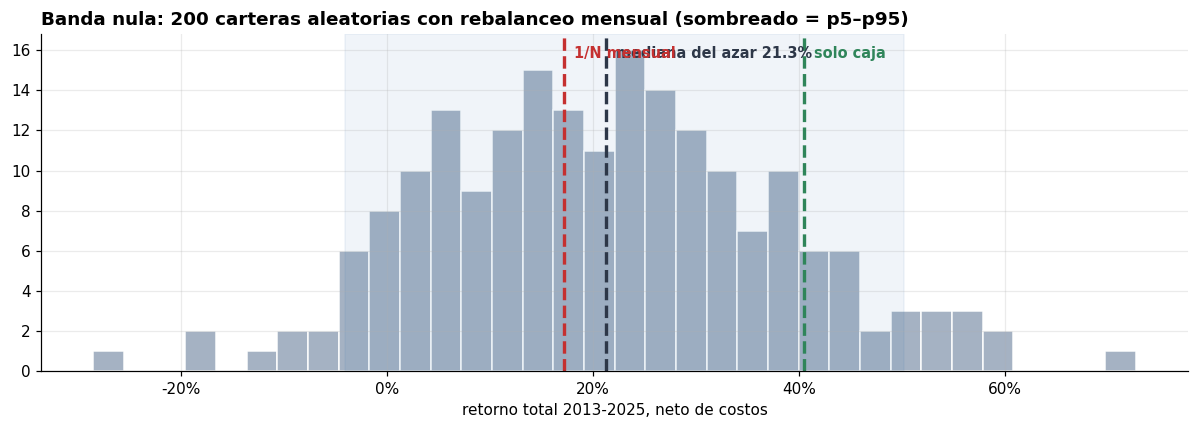

p5 -4.1% | mediana 21.3% | p95 50.2%

DEFECTO PROPIO CORREGIDO EN EL CAMINO (se anota, no se poda): la primera
versión re-sorteaba los pesos cada 21 días y daba una mediana de -60%. Eso no
medía la suerte de la ASIGNACIÓN: medía el costo de rotar la cartera entera
doce veces al año. Un null mal armado hace ver bien a cualquier cosa.


In [10]:
d = NULA["horizonte_completo"]["rebalanceo mensual"]
fig, ax = plt.subplots(figsize=(11, 4.0))
ax.hist(d["retornos"], bins=34, color=C["gris"], edgecolor="white", alpha=0.95)
for x, col, txt in [
    (d["mediana"], "#2d3748", f"mediana del azar {d['mediana']:.1%}"),
    (BASE["horizonte_completo"]["1/N mensual"]["retorno_total"], C["rojo"], "1/N mensual"),
    (BASE["horizonte_completo"]["solo caja"]["retorno_total"], C["caja"], "solo caja"),
]:
    ax.axvline(x, color=col, lw=2.2, ls="--")
    ax.text(x, ax.get_ylim()[1] * 0.93, "  " + txt, color=col, fontsize=9.5, fontweight="bold")
ax.axvspan(d["p5"], d["p95"], color=C["1N"], alpha=0.07)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("retorno total 2013-2025, neto de costos")
ax.set_title(f"Banda nula: {d['n']} carteras aleatorias con rebalanceo mensual "
             f"(sombreado = p5–p95)", loc="left")
plt.tight_layout(); plt.show()

print(f"p5 {d['p5']:.1%} | mediana {d['mediana']:.1%} | p95 {d['p95']:.1%}")
print("\nDEFECTO PROPIO CORREGIDO EN EL CAMINO (se anota, no se poda): la primera")
print("versión re-sorteaba los pesos cada 21 días y daba una mediana de -60%. Eso no")
print("medía la suerte de la ASIGNACIÓN: medía el costo de rotar la cartera entera")
print("doce veces al año. Un null mal armado hace ver bien a cualquier cosa.")

---
## 6 · La partición (D10): walk-forward con purga y embargo

Con 2013-2025, el corte obvio (train 2013-19 / val 2020-21 / test 2022-25) mete
**la pandemia y Castillo enteros en validación**, que es el régimen más raro de
los catorce años. Con pliegues, **cada uno *es* un régimen distinto** y se
reportan todos — lo que además contesta gratis la pregunta sobre quiebres de
régimen, en vez de discutir qué subperíodo excluir.

**El embargo de 20 días no es adorno:** las features llevan ventanas móviles
(medias de 20/50, EWMAs de 60, volatilidad de 20). Sin un hueco entre tramos, la
última observación de entrenamiento y la primera de validación comparten insumos.

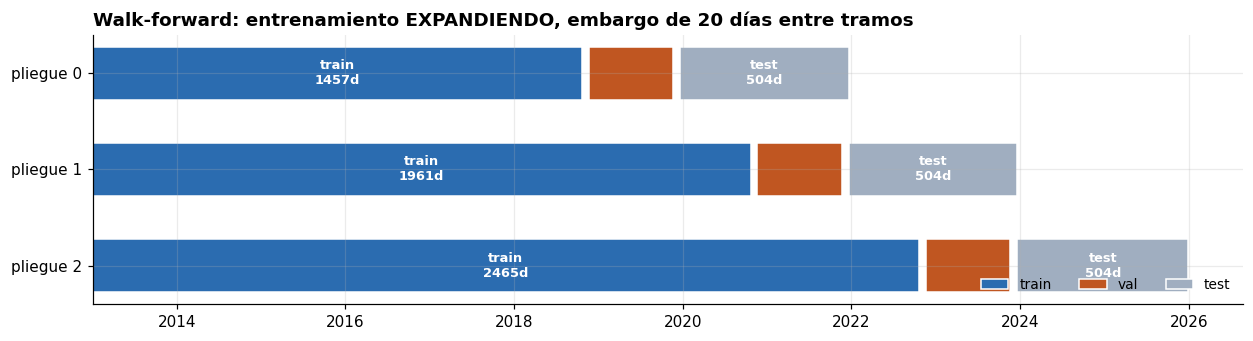

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 3.2))
colores = {"train": C["1N"], "val": C["agente"], "test": C["gris"]}
for k, f in enumerate(PLIEG["pliegues"]):
    for tramo in ("train", "val", "test"):
        t = f[tramo]
        x0, x1 = pd.Timestamp(t["desde"]), pd.Timestamp(t["hasta"])
        ax.barh(k, x1 - x0, left=x0, height=0.55, color=colores[tramo],
                edgecolor="white", label=tramo if k == 0 else None)
        if t["dias"] > 300:
            ax.text(x0 + (x1 - x0) / 2, k, f"{tramo}\n{t['dias']}d", ha="center",
                    va="center", color="white", fontsize=8.5, fontweight="bold")
ax.set_yticks(range(len(PLIEG["pliegues"])))
ax.set_yticklabels([f"pliegue {f['idx']}" for f in PLIEG["pliegues"]])
ax.invert_yaxis()
ax.set_title(f"Walk-forward: entrenamiento EXPANDIENDO, embargo de "
             f"{PLIEG['embargo_dias']} días entre tramos", loc="left")
ax.legend(ncol=3, loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

### 6.1 · Por qué reportar un solo pliegue sería engañoso

Los mismos baselines, sobre cada tramo de cada pliegue, **anualizados**.
La validación del pliegue 0 resultó ser **el mejor año de la década** para la BVL;
la de los pliegues 1 y 2 fueron años de caída. Con estos datos, cualquier
conclusión sacada de un pliegue único **mide el régimen, no al agente**.

,días,1/N diario,1/N trimestral,solo caja,maxDD del 1/N
tramo,,,,,
pliegue0_train,1456,1.45%,2.64%,2.63%,-46.4%
pliegue0_val,251,11.89%,13.08%,1.88%,-10.2%
pliegue1_train,1960,1.49%,2.67%,2.30%,-46.4%
pliegue1_val,251,-8.74%,-6.51%,0.28%,-42.6%
pliegue2_train,2464,-0.47%,0.73%,2.15%,-46.4%
pliegue2_val,251,-7.55%,-7.83%,5.40%,-11.3%


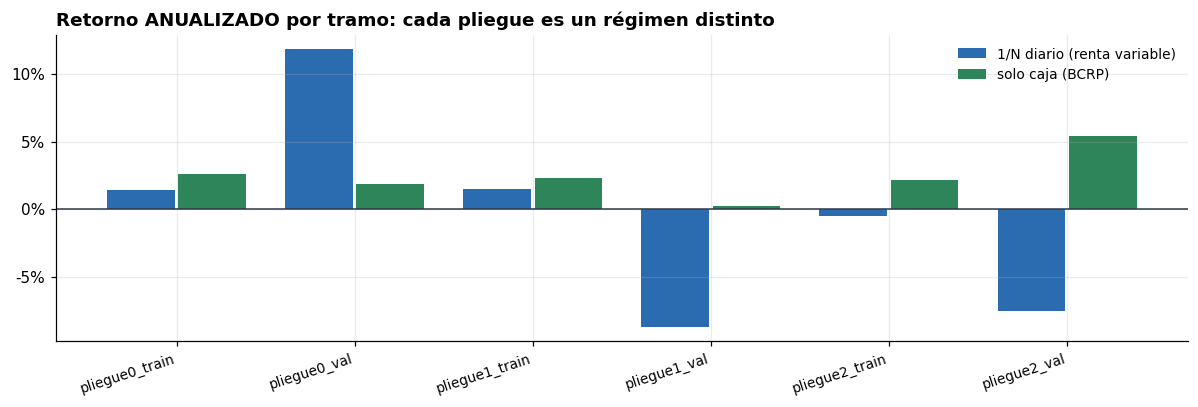

In [12]:
filas = []
for clave, v in BASE.items():
    if clave == "horizonte_completo":
        continue
    dias = v["1/N diario"]["dias"]
    ann = lambda x: (1 + x) ** (252 / dias) - 1
    filas.append({
        "tramo": clave,
        "días": dias,
        "1/N diario": ann(v["1/N diario"]["retorno_total"]),
        "1/N trimestral": ann(v["1/N trimestral"]["retorno_total"]),
        "solo caja": ann(v["solo caja"]["retorno_total"]),
        "maxDD del 1/N": v["1/N diario"]["max_drawdown"],
    })
reg = pd.DataFrame(filas).set_index("tramo")
display(reg.style.format({"1/N diario": "{:.2%}", "1/N trimestral": "{:.2%}",
                          "solo caja": "{:.2%}", "maxDD del 1/N": "{:.1%}"})
        .background_gradient(cmap="RdYlGn", subset=["1/N diario", "1/N trimestral"], vmin=-0.12, vmax=0.12))

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(reg))
ax.bar(x - 0.2, reg["1/N diario"], width=0.38, color=C["1N"], label="1/N diario (renta variable)")
ax.bar(x + 0.2, reg["solo caja"], width=0.38, color=C["caja"], label="solo caja (BCRP)")
ax.axhline(0, color="#2d3748", lw=1)
ax.set_xticks(x); ax.set_xticklabels(reg.index, rotation=18, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_title("Retorno ANUALIZADO por tramo: cada pliegue es un régimen distinto", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 6.2 · ¿Ventana que crece o ventana que se desplaza? *(pregunta del asesor)*

La observación del asesor es correcta y apunta al corazón del problema: **si el
mercado cambia de régimen, la data vieja deja de describir el presente.**

Lo primero: **la estructura por pliegues ya estaba contemplada e implementada**
(D10, `src/env/folds.py`). El esquema actual es exactamente
`train → val → train → val → train → val` deslizándose hacia adelante, y el primer
entrenamiento ya ocupa **44.7%** del periodo utilizable — muy cerca del ~50% que
propone.

Lo que **sí** queda abierto es otra cosa, más fina: el entrenamiento hoy
**EXPANDE** (siempre arranca en 2013 y crece). La alternativa que describe su
argumento es una ventana **MÓVIL** (*rolling*): largo fijo que descarta lo viejo.

,EXPANDING desde,días,% del periodo,ROLLING desde,días,días DESCARTADOS,% descartado
pliegue,,,,,,,
0,2013-01-02,1457,44.7%,2013-01-02,1457,0,0.0%
1,2013-01-02,1961,60.1%,2015-01-05,1457,504,25.7%
2,2013-01-02,2465,75.6%,2017-01-10,1457,1008,40.9%


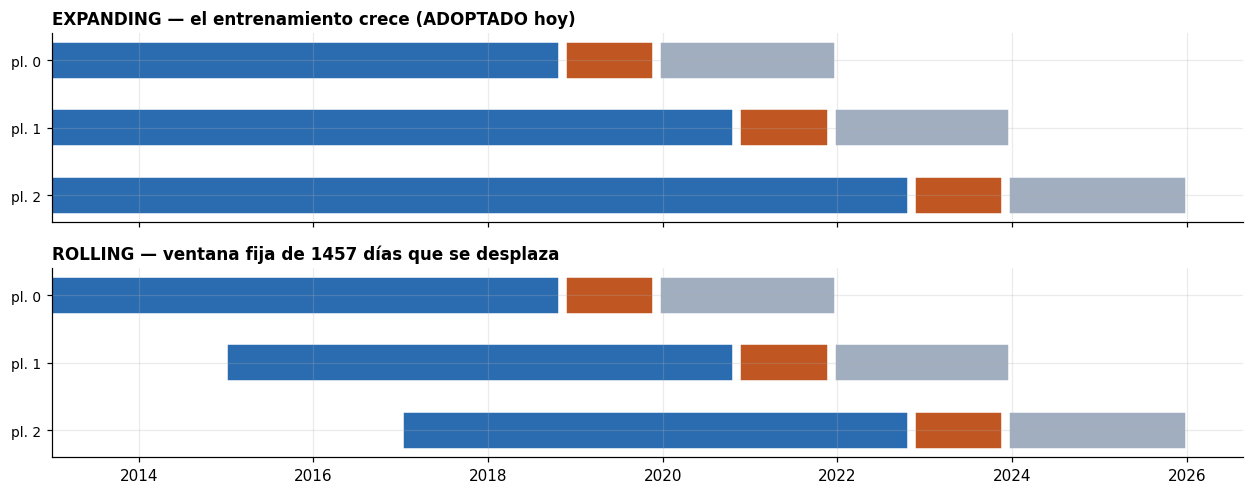

In [13]:
util = PLIEG["dias_utilizables"]
largo = PLIEG["largo_ventana_movil"]
comp = []
for pe, pr in zip(PLIEG["pliegues"], PLIEG["pliegues_rolling"]):
    comp.append({
        "pliegue": pe["idx"],
        "EXPANDING desde": pe["train"]["desde"], "días": pe["train"]["dias"],
        "% del periodo": pe["train"]["dias"] / util,
        "ROLLING desde": pr["train"]["desde"], "días ": pr["train"]["dias"],
        "días DESCARTADOS": pe["train"]["dias"] - pr["train"]["dias"],
        "% descartado": (pe["train"]["dias"] - pr["train"]["dias"]) / pe["train"]["dias"],
    })
display(pd.DataFrame(comp).set_index("pliegue").style.format(
    {"% del periodo": "{:.1%}", "% descartado": "{:.1%}"}))

fig, axes = plt.subplots(2, 1, figsize=(11.5, 4.6), sharex=True)
colores = {"train": C["1N"], "val": C["agente"], "test": C["gris"]}
for ax, clave, titulo in [(axes[0], "pliegues", "EXPANDING — el entrenamiento crece (ADOPTADO hoy)"),
                          (axes[1], "pliegues_rolling", f"ROLLING — ventana fija de {largo} días que se desplaza")]:
    for k, f in enumerate(PLIEG[clave]):
        for tramo in ("train", "val", "test"):
            t = f[tramo]
            x0, x1 = pd.Timestamp(t["desde"]), pd.Timestamp(t["hasta"])
            ax.barh(k, x1 - x0, left=x0, height=0.55, color=colores[tramo], edgecolor="white")
    ax.set_yticks(range(len(PLIEG[clave])))
    ax.set_yticklabels([f"pl. {f['idx']}" for f in PLIEG[clave]], fontsize=9)
    ax.invert_yaxis()
    ax.set_title(titulo, loc="left", fontsize=11)
plt.tight_layout(); plt.show()

#### ¿Y los datos qué dicen? — la pregunta convertida en medición

Si la data vieja realmente estorba, el tramo de entrenamiento **rolling** debería
parecerse **más** a su validación que el **expanding**. Se mide en volatilidad y
co-movimiento, que es lo que gobierna a un agente de portafolio.

Esto **no cuesta nada en el contador de D10**: son estadísticos del panel, no
estrategias entrenadas.

,vol VAL,vol train exp,vol train rol,corr VAL,corr train exp,corr train rol,más cerca (vol),más cerca (corr)
pliegue,,,,,,,,
pliegue0,0.238,0.243,0.243,0.066,0.170,0.170,idéntico,idéntico
pliegue1,0.439,0.252,0.264,0.255,0.148,0.151,rolling,rolling
pliegue2,0.225,0.286,0.304,0.018,0.181,0.182,expanding,expanding


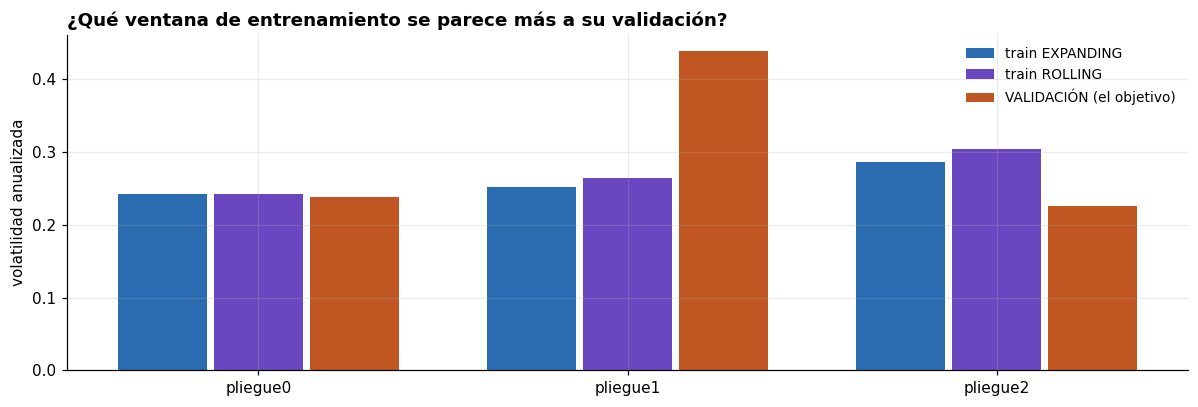

In [14]:
if REG is None:
    print("sin regimenes.json — regenera los artefactos")
else:
    filas = []
    for k, d in REG.items():
        filas.append({
            "pliegue": k,
            "vol VAL": d["val"]["vol_anual"], "vol train exp": d["train_expanding"]["vol_anual"],
            "vol train rol": d["train_rolling"]["vol_anual"],
            "corr VAL": d["val"]["corr_media"], "corr train exp": d["train_expanding"]["corr_media"],
            "corr train rol": d["train_rolling"]["corr_media"],
            "más cerca (vol)": d["mas_parecido_a_val"]["vol"],
            "más cerca (corr)": d["mas_parecido_a_val"]["corr"],
        })
    display(pd.DataFrame(filas).set_index("pliegue").style.format(
        {c: "{:.3f}" for c in ["vol VAL", "vol train exp", "vol train rol",
                               "corr VAL", "corr train exp", "corr train rol"]}))

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ks = list(REG)
    x = np.arange(len(ks))
    ax.bar(x - 0.26, [REG[k]["train_expanding"]["vol_anual"] for k in ks], width=0.24,
           color=C["1N"], label="train EXPANDING")
    ax.bar(x,        [REG[k]["train_rolling"]["vol_anual"] for k in ks], width=0.24,
           color=C["morado"], label="train ROLLING")
    ax.bar(x + 0.26, [REG[k]["val"]["vol_anual"] for k in ks], width=0.24,
           color=C["agente"], label="VALIDACIÓN (el objetivo)")
    ax.set_xticks(x); ax.set_xticklabels(ks)
    ax.set_ylabel("volatilidad anualizada")
    ax.set_title("¿Qué ventana de entrenamiento se parece más a su validación?", loc="left")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

#### La lectura, y es la respuesta a la pregunta

* **Pliegue 0: empate por construcción.** La ventana móvil se define con el largo
  de su propio entrenamiento, así que ambos esquemas miran el mismo tramo.
* **Pliegue 1: gana rolling**, pero por poco — y el dato que importa es otro:
  la validación tiene **vol 0.42** contra **0.25-0.26** de *cualquiera* de las dos
  ventanas. Es el año de la pandemia y Castillo. **Ningún tramo pasado se le
  parece**, así que recortar no lo arregla.
* **Pliegue 2: gana expanding.** La ventana móvil (2018-2022, con la pandemia
  adentro) se parece *menos* a su validación que el historial completo.

> **No hay evidencia de que la ventana móvil ayude en este panel.** El argumento
> del asesor es teóricamente correcto, pero acá el cambio de régimen es tan grande
> que descartar datos no acerca el entrenamiento al objetivo — solo lo empobrece.

#### Recomendación

1. **Mantener `expanding` como esquema primario.** Es lo que se haría en la
   práctica (reentrenar con todo lo conocido), y el dato escaso de este problema
   son los ~3,260 días: en el pliegue 2 el rolling **tira el 41% del entrenamiento**.
2. **Dejar `rolling` disponible como brazo de robustez.** Ya está implementado
   (`walk_forward(..., train_len=N)`), con tests, y no cambia el default.
3. **Pre-registrar la elección ANTES de correr.** Elegir entre las dos mirando cuál
   da mejor validación sería selección encubierta — exactamente la lección de D22 —
   y tendría que entrar al contador del Sharpe deflactado.
4. **Atacar el régimen donde sí se puede:** el problema real que destapó el piloto
   no es la ventana, es que `train` y `val` son regímenes opuestos (§6.1). Eso se
   ataca reportando **los tres pliegues** y con features que describan el régimen,
   no recortando historia.

#### Un detalle de la estructura que conviene tener presente

En cualquier walk-forward con entrenamiento que avanza, **el `test` de un pliegue
termina siendo `train` de los siguientes**. Acá:

In [15]:
filas = []
for j, fj in enumerate(PLIEG["pliegues"]):
    a0, a1 = fj["train"]["i0"], fj["train"]["i1"]
    for i, fi in enumerate(PLIEG["pliegues"]):
        if i >= j:
            continue
        b0, b1 = fi["test"]["i0"], fi["test"]["i1"]
        ov = max(0, min(a1, b1) - max(a0, b0))
        if ov:
            filas.append({"train del pliegue": j, "incluye test del pliegue": i,
                          "días": ov, "% de ese test": ov / fi["test"]["dias"]})
display(pd.DataFrame(filas).set_index(["train del pliegue", "incluye test del pliegue"])
        .style.format({"% de ese test": "{:.0%}"}))

**Esto NO es una fuga hacia el futuro** — que el pliegue 2 entrene con 2019-2021
para predecir 2023-2025 es legítimo: esos datos ya son pasado, y es justo lo que
uno haría en la práctica. Pero tiene **dos consecuencias que hay que declarar**:

1. **Los tres resultados de prueba no son independientes.** No se pueden juntar
   como tres observaciones independientes para construir un intervalo de confianza;
   los IC salen de las **semillas**, no de los pliegues.
2. **El orden importa.** Una vez que se mira el `test` del pliegue 0, cualquier
   cambio de diseño posterior contamina los pliegues 1 y 2. En la práctica: se
   congela el pre-registro **una vez** y se corren los tres seguidos.

*(La ventana móvil tampoco arregla esto: con 1,458 días, el `train` rolling del
pliegue 2 sigue conteniendo el `test` completo del pliegue 0.)*

---
## 7 · El agente — piloto de D21

**PPO**, red 64×64 (a propósito chica: ~3,300 días de *una sola trayectoria
histórica*), vista `solo_mercado`, recompensa DSR, 150k pasos, 3 semillas,
pliegue 0, evaluado sobre **validación**.

> El tramo de prueba no se toca. Estos números son **diagnóstico de plomería**.

### 7.1 · Curvas de entrenamiento y modelos guardados — la acreditación de **R7**

El documento de tesis pide para R7 *«curvas de entrenamiento; modelos almacenados»*
y *«convergencia estable de las curvas de recompensa en al menos 3 semillas por
algoritmo»*. **Hasta el 2026-09-11 esto no se producía**: se entrenaba con
`verbose=0` y sin `model.save()`, así que el agente existía pero R7 no se
acreditaba. Ahora se registran las dos cosas.

> **Ojo con cómo se lee la curva.** Con `random_start` los episodios tienen largo
> variable, así que la recompensa *acumulada* por episodio mezcla "lo bien que le
> fue" con "cuán largo fue". Lo comparable es la **recompensa por paso**, que es
> lo que se grafica.

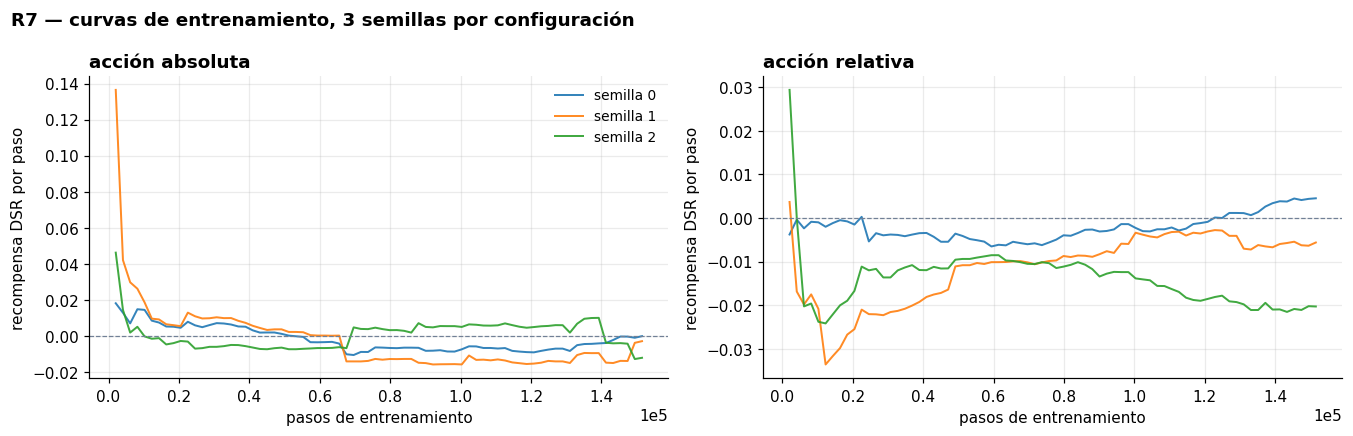


¿meseta? último 10% de la curva contra el 10% anterior:
   logits  semilla 0: +0.0046
   logits  semilla 1: +0.0018
   logits  semilla 2: -0.0109
   delta   semilla 0: +0.0029
   delta   semilla 1: -0.0006
   delta   semilla 2: -0.0012


In [16]:
if not HAY_AGENTE:
    print("sin artefactos del agente")
elif "agente_delta_s0__tr_pasos" not in CURVAS.files:
    print("los artefactos son de una corrida ANTERIOR al registro de curvas.")
    print("Regenera con: python scripts/genera_artefactos_oe1.py")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0))
    for ax, (modo, titulo, col) in zip(axes, [("logits", "acción absoluta", C["morado"]),
                                              ("delta", "acción relativa", C["agente"])]):
        for s in range(AGENTE["config"]["semillas"]):
            x = CURVAS[f"agente_{modo}_s{s}__tr_pasos"]
            y = CURVAS[f"agente_{modo}_s{s}__tr_recompensa_paso"]
            ax.plot(x, y, lw=1.3, alpha=0.9, label=f"semilla {s}")
        ax.axhline(0, color="#718096", lw=0.8, ls="--")
        ax.set_xlabel("pasos de entrenamiento")
        ax.set_ylabel("recompensa DSR por paso")
        ax.set_title(titulo, loc="left")
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    axes[0].legend(fontsize=9)
    fig.suptitle("R7 — curvas de entrenamiento, 3 semillas por configuración",
                 x=0.012, ha="left", fontweight="bold", fontsize=12)
    plt.tight_layout(); plt.show()

    # Estabilidad entre semillas: es literalmente el indicador que pide el PDF.
    filas = []
    for modo in ("logits", "delta"):
        for s in range(AGENTE["config"]["semillas"]):
            y = CURVAS[f"agente_{modo}_s{s}__tr_recompensa_paso"]
            n = max(1, len(y) // 5)
            filas.append({"modo": modo, "semilla": s,
                          "primer 20%": float(y[:n].mean()),
                          "último 20%": float(y[-n:].mean()),
                          "mejora": float(y[-n:].mean() - y[:n].mean()),
                          "modelo": AGENTE["resultados"][modo][s].get("modelo_guardado", "—")})
    display(pd.DataFrame(filas).set_index(["modo", "semilla"]).style.format(
        {"primer 20%": "{:.4f}", "último 20%": "{:.4f}", "mejora": "{:+.4f}"}))

    # ¿Llegó a meseta? Se compara el último 10% de la curva contra el 10% previo.
    # Es la pregunta que el indicador de R7 ("convergencia estable") exige
    # contestar, y no se puede contestar mirando solo las métricas finales.
    print("\n¿meseta? último 10% de la curva contra el 10% anterior:")
    for modo in ("logits", "delta"):
        for s in range(AGENTE["config"]["semillas"]):
            y = CURVAS[f"agente_{modo}_s{s}__tr_recompensa_paso"]
            m = max(1, len(y) // 10)
            print(f"   {modo:7s} semilla {s}: {y[-m:].mean() - y[-2*m:-m].mean():+.4f}")

**Lo que dicen las curvas, y no se veía en las métricas finales:**

1. **Con acción absoluta, entrenar EMPEORA la política** — las tres semillas caen
   (−0.029, −0.006, −0.004). Es la misma conclusión de D22, pero ahora vista
   *durante* el entrenamiento y no inferida del resultado en validación.
2. **Con acción relativa, dos de tres semillas mejoran** (+0.004, +0.018) y una
   empeora (−0.003). Es coherente con la dispersión de §7.5.
3. **Las curvas no llegan a meseta a los 150k pasos.** En 5 de 6 corridas el
   último 10% de la curva sigue por encima del 10% anterior.

> **RESUELTO EL 18-SEP — y el indicador de R7 queda acreditado.** Con
> 1,000,000 de pasos y 10 semillas, **9 de 10 curvas hacen meseta** (mediana
> ~750k) y la recompensa por paso sube en *las diez*. El documento pide
> «convergencia estable de las curvas de recompensa en al menos 3 semillas»:
> con 9 de 10, **cumplido**. Lo que faltaba no era el agente ni los artefactos,
> era presupuesto.
>
> Y ahí aparece el problema, que es otro y más interesante: **la curva sube y la
> validación baja**. Ver §7c.

*Advertencia al leer el eje:* el DSR es una recompensa **auto-referencial** (depende
de la propia historia de retornos del agente), así que su nivel absoluto no es
comparable entre configuraciones — solo su **tendencia dentro de una corrida**.

### 7.2 · El hallazgo que casi arruina la corrida (D22)

La primera corrida **empeoró** al entrenar: de rotación 1.57 a 43.5 al año, y
−19.7% de retorno. Parecía evidencia sobre la BVL. **No lo era: era la
parametrización de la exploración.**

En un espacio de acción de símplex, el ruido gaussiano de PPO se aplica a los
logits, y con el **defecto de SB3** (`log_std_init = 0`, σ=1) eso **re-sortea la
asignación completa en cada paso**. El agente pasa el entrenamiento pagando un
peaje gigantesco que **no produce su acción media sino el ruido** — el gradiente
no puede atribuirlo a μ, así que no hay por dónde aprender a no rotar.

La celda siguiente mide la rotación de una red **sin entrenar**: toda la que se
ve es peaje del ruido.

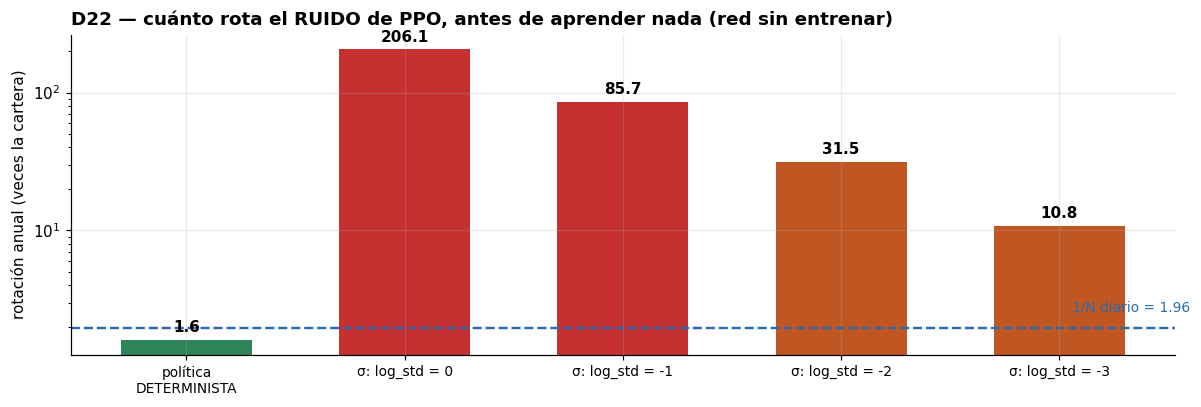

El criterio de calibración, y es la parte que importa para la honestidad:
la escala de exploración se elige por la ROTACIÓN, NUNCA por el retorno o el
Sharpe. Un hiperparámetro elegido mirando el desempeño en validación es
selección encubierta y tendría que entrar al contador de D10.


In [17]:
if EXPLOR is None:
    print("sin exploracion.json — corre scripts/genera_artefactos_oe1.py sin --sin-agente")
else:
    orden = ["determinista"] + [k for k in EXPLOR if k != "determinista"]
    rot = pd.Series({k: EXPLOR[k]["rotacion_anual"] for k in orden})
    etiquetas = ["política\nDETERMINISTA"] + [k.replace("estocastica_log_std_", "σ: log_std = ")
                                              for k in orden[1:]]
    fig, ax = plt.subplots(figsize=(11, 3.8))
    colores = [C["caja"]] + [C["rojo"] if v > 60 else C["agente"] for v in rot[1:]]
    b = ax.bar(range(len(rot)), rot.values, color=colores, width=0.6)
    ax.bar_label(b, fmt="%.1f", fontsize=10, fontweight="bold", padding=3)
    ax.axhline(1.96, color=C["1N"], ls="--", lw=1.6)
    ax.text(len(rot) - 0.4, 2.6, "1/N diario = 1.96", color=C["1N"], fontsize=9, ha="right")
    ax.set_yscale("log"); ax.set_ylabel("rotación anual (veces la cartera)")
    ax.set_xticks(range(len(rot))); ax.set_xticklabels(etiquetas, fontsize=9)
    ax.set_title("D22 — cuánto rota el RUIDO de PPO, antes de aprender nada (red sin entrenar)", loc="left")
    plt.tight_layout(); plt.show()
    print("El criterio de calibración, y es la parte que importa para la honestidad:")
    print("la escala de exploración se elige por la ROTACIÓN, NUNCA por el retorno o el")
    print("Sharpe. Un hiperparámetro elegido mirando el desempeño en validación es")
    print("selección encubierta y tendría que entrar al contador de D10.")

### 7.3 · La enmienda de D2: que "no operar" sea alcanzable

Resuelta la exploración, quedó un problema **estructural**: con una acción
*absoluta* (`w = softmax(a)`), cada paso produce un vector de pesos nuevo, y
quedarse quieto exige que la red reproduzca exactamente su salida anterior —
un accidente, no un estado alcanzable. El agente seguía rotando 9 veces al año.

**La acción pasó a ser un ajuste sobre los pesos actuales:**

$$a \;\longrightarrow\; w_{obj} = \text{normaliza}\big(\max(w_{actual} + s\cdot\tanh(a),\,0)\big)$$

Con eso `a = 0` **devuelve exactamente la cartera actual**: no operar es el punto
natural de la política, y el ruido perturba *el cambio*, no *la posición*.

In [18]:
if not HAY_AGENTE:
    print("sin agente.json — corre scripts/genera_artefactos_oe1.py sin --sin-agente")
else:
    def med(modo, clave):
        return float(np.median([r[clave] for r in AGENTE["resultados"][modo]]))
    ref = BASE[f"pliegue{AGENTE['config']['pliegue']}_val"]
    comp = pd.DataFrame([
        {"configuración": "acción ABSOLUTA (softmax)", "rot/año": med("logits", "rotacion_anual"),
         "retorno": med("logits", "retorno_total"), "sharpe": med("logits", "sharpe"),
         "maxDD": med("logits", "max_drawdown"), "caja media": med("logits", "peso_caja_medio")},
        {"configuración": "acción RELATIVA (delta) ←", "rot/año": med("delta", "rotacion_anual"),
         "retorno": med("delta", "retorno_total"), "sharpe": med("delta", "sharpe"),
         "maxDD": med("delta", "max_drawdown"), "caja media": med("delta", "peso_caja_medio")},
        {"configuración": "1/N diario (referencia)", "rot/año": ref["1/N diario"]["rotacion_anual"],
         "retorno": ref["1/N diario"]["retorno_total"], "sharpe": ref["1/N diario"]["sharpe"],
         "maxDD": ref["1/N diario"]["max_drawdown"], "caja media": np.nan},
        {"configuración": "solo caja (referencia)", "rot/año": 0.0,
         "retorno": ref["solo caja"]["retorno_total"], "sharpe": ref["solo caja"]["sharpe"],
         "maxDD": ref["solo caja"]["max_drawdown"], "caja media": 1.0},
    ]).set_index("configuración")
    print("mediana de 3 semillas · pliegue 0 · VALIDACIÓN (2018-11-23 → 2019-11-22)\n")
    display(comp.style.format({"rot/año": "{:.2f}", "retorno": "{:.1%}", "sharpe": "{:.2f}",
                               "maxDD": "{:.1%}", "caja media": "{:.1%}"}, na_rep="—"))

mediana de 3 semillas · pliegue 0 · VALIDACIÓN (2018-11-23 → 2019-11-22)



,rot/año,retorno,sharpe,maxDD,caja media
configuración,,,,,
acción ABSOLUTA (softmax),9.18,3.8%,0.23,-11.5%,12.8%
acción RELATIVA (delta) ←,1.97,2.6%,0.18,-4.2%,62.2%
1/N diario (referencia),1.97,11.8%,0.90,-10.2%,—
solo caja (referencia),0.00,1.9%,0.00,0.0%,100.0%


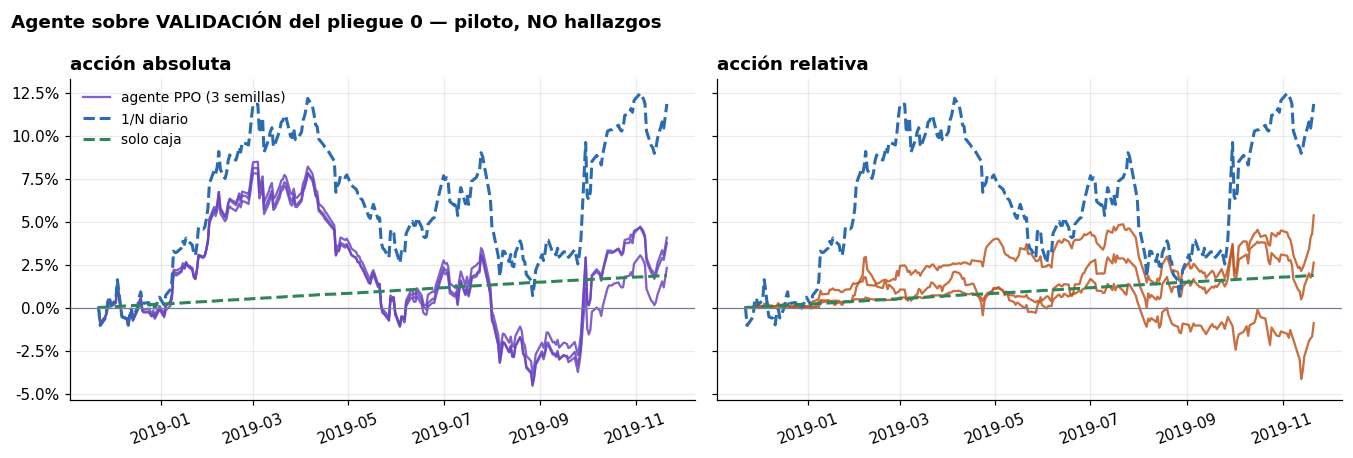

In [19]:
if HAY_AGENTE:
    modos = [("logits", "acción absoluta", C["morado"]), ("delta", "acción relativa", C["agente"])]
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2), sharey=True)
    for ax, (modo, titulo, col) in zip(axes, modos):
        for s in range(AGENTE["config"]["semillas"]):
            eq = CURVAS[f"agente_{modo}_s{s}__equity"]
            fe = pd.to_datetime(CURVAS[f"agente_{modo}_s{s}__fechas"])
            ax.plot(fe, eq / eq[0] - 1, color=col, lw=1.5, alpha=0.85,
                    label="agente PPO (3 semillas)" if s == 0 else None)
        for etiqueta, c2, lw in [("1/N diario", C["1N"], 2.0), ("solo caja", C["caja"], 2.0)]:
            eq, fe = curva(f"val_f0__{etiqueta}")
            ax.plot(fe, eq / eq[0] - 1, color=c2, lw=lw, ls="--", label=etiqueta)
        ax.axhline(0, color="#718096", lw=0.8)
        ax.yaxis.set_major_formatter(pct1)
        ax.set_title(titulo, loc="left")
        ax.tick_params(axis="x", rotation=20)
    axes[0].legend(fontsize=9, loc="upper left")
    fig.suptitle("Agente sobre VALIDACIÓN del pliegue 0 — piloto, NO hallazgos",
                 x=0.012, ha="left", fontweight="bold", fontsize=12)
    plt.tight_layout(); plt.show()

### 7.4 · Apareció un comportamiento nuevo: el agente se va a la caja

La acción relativa hizo lo que apuntaba (rotación 2.01 contra 1.96 del 1/N) y el
drawdown mejoró. Pero **el agente se pone ~65% en caja**. Eso **no** es el
artefacto de arranque — ese explicaría ~4% de caja media, no 65%. **El agente
elige la caja.**

**Y elige bien.** En su tramo de entrenamiento (2013-01 → 2018-10), la caja
rindió 2.63%/año contra 1.65%/año del 1/N, con drawdown 0% contra −46.5%. Con una
recompensa que penaliza volatilidad, **quedarse en caja es la respuesta correcta a
lo que el agente vio**. Que la validación resultara el mejor año de la década es
una propiedad del corte, no un error del agente.

> **El agente no falló: `train` y `val` son regímenes opuestos.** Por eso los tres
> pliegues dejan de ser una mejora metodológica y pasan a ser un **requisito**.

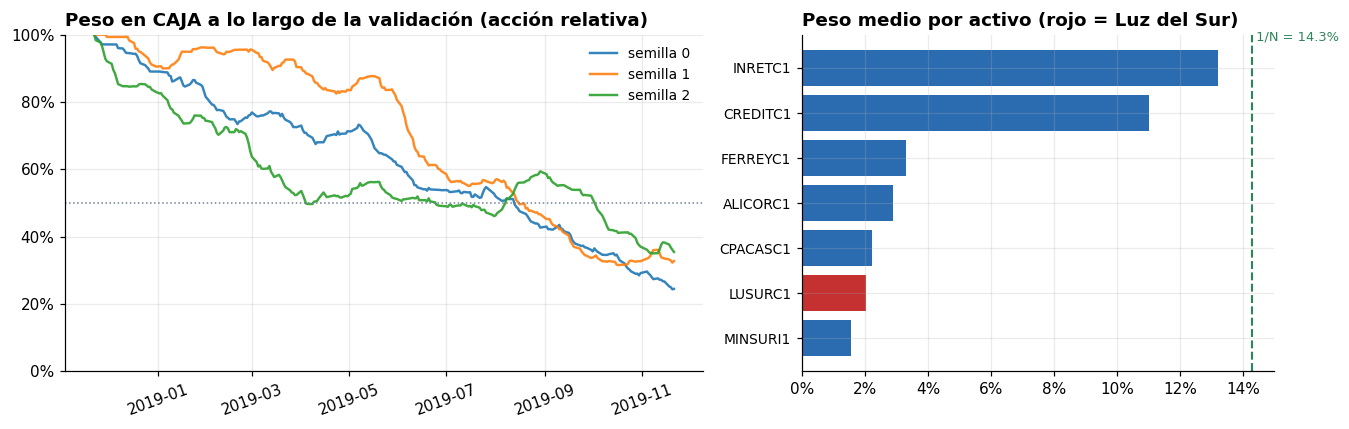

VERIFICACIÓN A5 (propuesta por el especialista): Luz del Sur es el activo más
caro de operar (323 pbs ida y vuelta).
Si el modelo de costos funciona, el peso del agente ahí debe tender a cero.
   peso medio del agente en LUSURC1: 2.04%   (1/N sería 14.3%)

MATIZ HONESTO: CREDITC1 es el SEGUNDO más caro (268 pbs) y se queda con
11.0%. El agente no está simplemente ordenando por costo.


In [20]:
if HAY_AGENTE:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.0), gridspec_kw={"width_ratios": [1.35, 1]})

    for s in range(AGENTE["config"]["semillas"]):
        w = CURVAS[f"agente_delta_s{s}__pesos"]
        fe = pd.to_datetime(CURVAS[f"agente_delta_s{s}__fechas"])
        a1.plot(fe, w[:, -1], lw=1.6, alpha=0.9, label=f"semilla {s}")
    a1.axhline(0.5, color="#718096", ls=":", lw=1)
    a1.set_ylim(0, 1); a1.yaxis.set_major_formatter(pct)
    a1.set_title("Peso en CAJA a lo largo de la validación (acción relativa)", loc="left")
    a1.legend(fontsize=9); a1.tick_params(axis="x", rotation=20)

    pm = pd.DataFrame({
        f"semilla {s}": {t: np.mean(CURVAS[f"agente_delta_s{s}__pesos"][:, j])
                         for j, t in enumerate(TICKERS)}
        for s in range(AGENTE["config"]["semillas"])
    })
    pm = pm.mean(axis=1).sort_values()
    cols = [C["rojo"] if t == "LUSURC1" else C["1N"] for t in pm.index]
    a2.barh(range(len(pm)), pm.values, color=cols)
    a2.set_yticks(range(len(pm))); a2.set_yticklabels(pm.index, fontsize=9)
    a2.axvline(1 / 7, color=C["caja"], ls="--", lw=1.4)
    a2.text(1 / 7, len(pm) - 0.4, " 1/N = 14.3%", color=C["caja"], fontsize=8.5)
    a2.xaxis.set_major_formatter(pct)
    a2.set_title("Peso medio por activo (rojo = Luz del Sur)", loc="left")
    plt.tight_layout(); plt.show()

    lusur = pm.get("LUSURC1", np.nan)
    print(f"VERIFICACIÓN A5 (propuesta por el especialista): Luz del Sur es el activo más")
    print(f"caro de operar ({COSTOS['roundtrip_bps_por_nocional']['250000']['LUSURC1']:.0f} pbs ida y vuelta).")
    print(f"Si el modelo de costos funciona, el peso del agente ahí debe tender a cero.")
    print(f"   peso medio del agente en LUSURC1: {lusur:.2%}   (1/N sería 14.3%)")
    print(f"\nMATIZ HONESTO: CREDITC1 es el SEGUNDO más caro (268 pbs) y se queda con")
    print(f"{pm.get('CREDITC1', np.nan):.1%}. El agente no está simplemente ordenando por costo.")

### 7.5 · Cuidado: la media de caja mide sobre todo la VELOCIDAD DE ENTRADA

El gráfico de la izquierda obliga a matizar la lectura anterior. El portafolio
**arranca 100% en caja**, y con la acción relativa el agente solo puede moverse
5 pp por paso: la serie **empieza en ~95% y baja monótonamente** durante todo el
año. O sea, ese "65% en caja" promedio **está dominado por el camino de entrada**,
no por una preferencia de estado estacionario.

In [21]:
if HAY_AGENTE:
    filas = []
    for modo in ("delta", "logits"):
        for s in range(AGENTE["config"]["semillas"]):
            w = CURVAS[f"agente_{modo}_s{s}__pesos"][:, -1]
            filas.append({"modo": modo, "semilla": s, "caja MEDIA": w.mean(),
                          "primer mes": w[:21].mean(), "último mes": w[-21:].mean(),
                          "último día": w[-1], "días > 50% caja": (w > 0.5).mean()})
    caja_tab = pd.DataFrame(filas).set_index(["modo", "semilla"])
    display(caja_tab.style.format("{:.1%}"))

**Qué dice realmente la tabla, y hay que decirlo así:**

* Con acción **relativa**, las tres semillas arrancan en ~95% de caja y terminan en
  **47.8%, 12.3% y 1.1%**. El agente **está entrando al mercado**, despacio. No se
  queda en caja: *tarda* en salir de ella.
* Con acción **absoluta**, el agente salta a ~12% de caja en los primeros días y se
  queda ahí. No hay camino de entrada porque el `softmax` fija el objetivo directo.
* **Por lo tanto la comparación "12.6% vs 64.9% de caja" entre los dos modos no es
  limpia:** mezcla la velocidad de entrada con la preferencia de estado estacionario.

Esto **no refuta** la lectura de D21 —en su tramo de entrenamiento la caja
efectivamente le ganó a la renta variable, y las semillas terminan en puntos muy
distintos (1.1% a 47.8%)— pero sí obliga a **medirla de otra forma**: comparar el
estado estacionario (último tercio del tramo), o arrancar el episodio ya invertido
en 1/N para que la caja sea una decisión y no una condición inicial.

> **Esta es una decisión de diseño pendiente, no un resultado.** Va al registro.

**Varianza entre semillas.** El peso final en caja va de 1.1% a 47.8%. Cuando la
política decide algo casi binario (dentro o fuera del mercado), la dispersión entre
semillas se traduce directamente en dispersión de retorno. Refuerza el mínimo de
**10 semillas** y el reporte por **mediana e intercuartil**, nunca por la mejor semilla.

---
## 7b · R8 — la ablación de canales

**La pregunta de R8:** ¿aporta cada canal de señal, y cuánto? Cuatro brazos, cada
uno agregando **un solo canal** sobre la misma base de mercado. 36 corridas
(4 vistas × 3 pliegues × 3 semillas), sobre **validación**.

*Dos defectos propios hubo que arreglar antes de poder correrla: las vistas
mezclaban macro (12-sep) y la sorpresa fundamental entraba sin winsorizar
(D27, 18-sep). Con cualquiera de los dos, el resultado habría sido inatribuible.*

In [22]:
if ABLA is None:
    print("(no hay ablacion_r8.json — corre scripts/ablacion_r8.py)")
else:
    V, BB = ABLA["vistas"], ABLA["baselines"]
    FOLDS = ["pliegue0", "pliegue1", "pliegue2"]
    filas = []
    for f in FOLDS:
        for v in V:
            r = V[v][f]
            filas.append({"pliegue": f[-1], "brazo": v,
                          "ret": np.median([x["retorno_total"] for x in r]),
                          "sharpe": np.median([x["sharpe"] for x in r]),
                          "maxDD": np.median([x["max_drawdown"] for x in r]),
                          "rot": np.median([x["rotacion_anual"] for x in r]),
                          "caja": np.median([x["peso_caja_medio"] for x in r])})
        for et in ("1/N diario", "solo caja"):
            s_ = BB[f][et]
            filas.append({"pliegue": f[-1], "brazo": "· " + et,
                          "ret": s_["retorno_total"], "sharpe": s_["sharpe"],
                          "maxDD": s_["max_drawdown"], "rot": s_["rotacion_anual"],
                          "caja": np.nan})
    t = pd.DataFrame(filas).set_index(["pliegue", "brazo"])
    display(t.style.format({"ret": "{:+.1%}", "sharpe": "{:.2f}", "maxDD": "{:.1%}",
                            "rot": "{:.2f}", "caja": "{:.1%}"}, na_rep="—"))

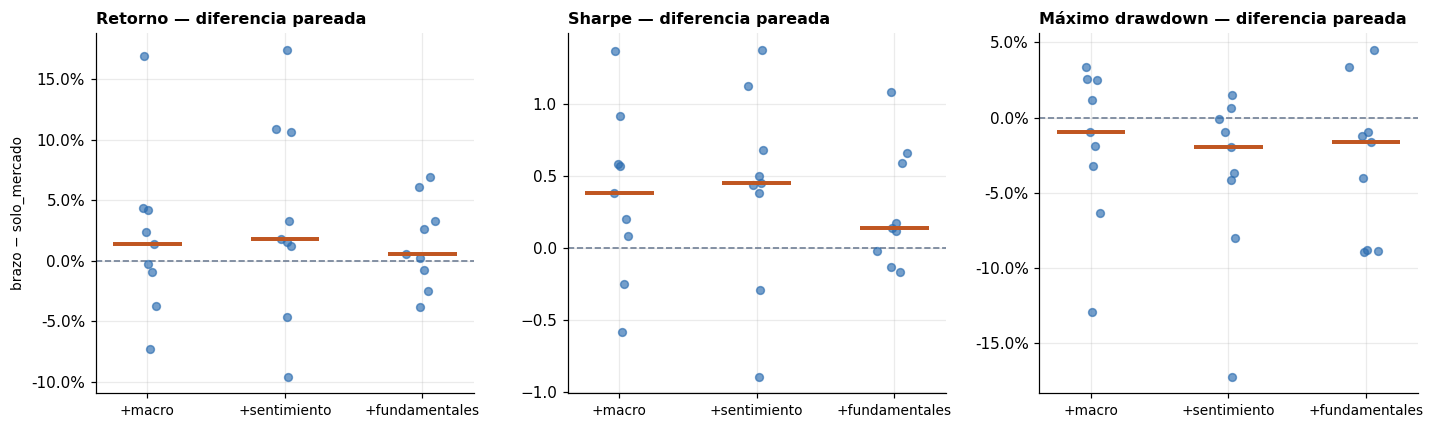

In [23]:
if ABLA is not None:
    V = ABLA["vistas"]; FOLDS = ["pliegue0", "pliegue1", "pliegue2"]; B0 = "solo_mercado"
    brazos = [v for v in V if v != B0]
    fig, ejes = plt.subplots(1, 3, figsize=(13.2, 4.0))
    for ax, clave, titulo in zip(
            ejes, ["retorno_total", "sharpe", "max_drawdown"],
            ["Retorno", "Sharpe", "Máximo drawdown"]):
        for i, v in enumerate(brazos):
            dif = [a[clave] - b[clave] for f in FOLDS
                   for a, b in zip(V[v][f], V[B0][f])]
            ax.scatter(np.full(len(dif), i) + np.random.default_rng(i).normal(0, .05, len(dif)),
                       dif, s=26, alpha=.65, color=C["1N"], zorder=3)
            ax.hlines(np.median(dif), i - .25, i + .25, color=C["agente"], lw=2.6, zorder=4)
        ax.axhline(0, color="#718096", lw=1.1, ls="--")
        ax.set_xticks(range(len(brazos)))
        ax.set_xticklabels([v.replace("mercado_", "+") for v in brazos], fontsize=9)
        ax.set_title(titulo + " — diferencia pareada", loc="left", fontsize=10.5)
    ejes[0].yaxis.set_major_formatter(pct1); ejes[2].yaxis.set_major_formatter(pct1)
    ejes[0].set_ylabel("brazo − solo_mercado", fontsize=9)
    plt.tight_layout(); plt.show()

**Cada punto es una semilla comparada contra su semilla pareada en la base**; la
barra naranja es la mediana. Cuatro lecturas, y **la primera manda**:

1. **La dispersión se come las diferencias.** El brazo de sentimiento en el
   pliegue 0 da `[−2.0%, +9.7%, +22.8%]` — 25 puntos de rango dentro de una sola
   celda, contra una mejora mediana de 1.8 puntos. **Con tres semillas esto es
   plomería, no evidencia.**
2. **El Sharpe y el retorno se contradicen.** En el pliegue 1 el sentimiento
   pierde **4.6 puntos más** que la base y su Sharpe sale **0.40 mejor**, porque
   su volatilidad es 20.6% contra 12.0%: con exceso negativo, dividir entre más
   volatilidad acerca el Sharpe a cero. De las 21 veces que un canal subió la
   volatilidad, el Sharpe "mejoró" 15. *Si R8 se lee del Sharpe solo, premia al
   canal que agrega riesgo en los tramos perdedores.*
3. **Ningún canal mueve la vara de D9:** los cuatro brazos van 1 de 3 contra la
   caja, y el pliegue que ganan es el 0 — el mejor año de la década.
4. **Los tres canales empeoran el drawdown**, que era la única ventaja clara del
   agente. *Macro lo calma* (rotación 1.50, el más barato); *sentimiento lo
   agita* (+40% de rotación, +37% de costo); *fundamentales lo saca de la caja* y
   le da el peor drawdown.

> **No se cierra D11.** El sentimiento tiene la mayor mejora de Sharpe *y* el peor
> drawdown *y* el mayor costo *y* es el único que empeora contra el 1/N. A tres
> semillas eso no es un veredicto, es un empate ruidoso.

---
## 7c · D25 — el presupuesto de pasos: **entrenar más lo empeora**

10 semillas × 1,000,000 de pasos, con evaluación en validación a los 150k, 300k,
600k y 1M. Es el resultado más informativo del proyecto, y es **negativo**.

In [24]:
if D25 is None:
    print("(no hay d25_presupuesto.json — corre scripts/d25_presupuesto.py)")
else:
    S = D25["semillas"]; CKP = D25["config"]["checkpoints"]
    col = lambda c, k: [e[k] for s_ in S.values() for e in s_["checkpoints"] if e["pasos"] == c]
    t = pd.DataFrame([{
        "pasos": f"{c:,}",
        "ret": np.median(col(c, "retorno_total")),
        "sharpe": np.median(col(c, "sharpe")),
        "maxDD": np.median(col(c, "max_drawdown")),
        "rotación": np.median(col(c, "rotacion_anual")),
        "caja": np.median(col(c, "peso_caja_medio")),
        "costo S/": np.median(col(c, "costo_total")),
        "rango entre semillas": max(col(c, "retorno_total")) - min(col(c, "retorno_total")),
    } for c in CKP]).set_index("pasos")
    display(t.style.format({"ret": "{:+.1%}", "sharpe": "{:.2f}", "maxDD": "{:.1%}",
                            "rotación": "{:.2f}", "caja": "{:.1%}", "costo S/": "{:,.0f}",
                            "rango entre semillas": "{:.1%}"}))
    mej = sum(1 for s_ in S.values()
              if next(e["retorno_total"] for e in s_["checkpoints"] if e["pasos"] == CKP[-1])
                 > next(e["retorno_total"] for e in s_["checkpoints"] if e["pasos"] == CKP[0]))
    print()
    print(f"semillas que MEJORAN de {CKP[0]:,} a {CKP[-1]:,} pasos: {mej}/{len(S)}")
    mesetas = [d["meseta"]["meseta_en"] for d in S.values() if d["meseta"].get("meseta_en")]
    print(f"curvas que hacen MESETA: {len(mesetas)}/{len(S)}  ·  mediana ~{int(np.median(mesetas)):,} pasos")
    print("-> el indicador de R7 que pide el documento (convergencia estable en >=3 semillas) QUEDA CUMPLIDO.")

,ret,sharpe,maxDD,rotación,caja,costo S/,rango entre semillas
pasos,,,,,,,
"150,000",+3.0%,0.30,-3.5%,1.91,68.0%,"31,066",8.4%
"300,000",+1.0%,-0.05,-5.6%,2.95,60.1%,"47,352",10.7%
"600,000",+1.9%,0.04,-6.0%,4.46,48.4%,"72,112",8.6%
"1,000,000",+1.4%,-0.01,-6.4%,5.18,53.6%,"82,699",7.9%



semillas que MEJORAN de 150,000 a 1,000,000 pasos: 1/10
curvas que hacen MESETA: 9/10  ·  mediana ~754,688 pasos
-> el indicador de R7 que pide el documento (convergencia estable en >=3 semillas) QUEDA CUMPLIDO.


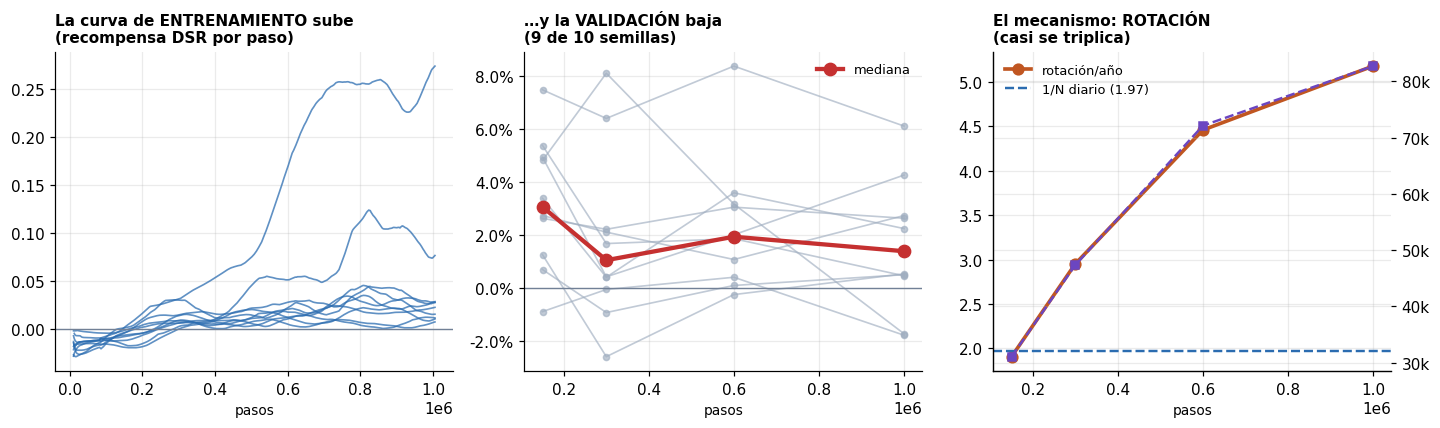

In [25]:
if D25 is not None and D25C is not None:
    S = D25["semillas"]; CKP = D25["config"]["checkpoints"]
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13.2, 4.0))

    for k in range(len(S)):
        p_, r_ = D25C[f"s{k}__pasos"], D25C[f"s{k}__recompensa_paso"]
        suav = pd.Series(r_).rolling(40, min_periods=5).mean()
        a1.plot(p_, suav, lw=1.1, alpha=.75, color=C["1N"])
    a1.axhline(0, color="#718096", lw=.9)
    a1.set_title("La curva de ENTRENAMIENTO sube\n(recompensa DSR por paso)", loc="left", fontsize=10)
    a1.set_xlabel("pasos", fontsize=9)

    for k, s_ in enumerate(S.values()):
        r_ = [next(e["retorno_total"] for e in s_["checkpoints"] if e["pasos"] == c) for c in CKP]
        a2.plot(CKP, r_, "o-", lw=1.1, ms=4, alpha=.65, color=C["gris"])
    med = [np.median([next(e["retorno_total"] for e in s_["checkpoints"] if e["pasos"] == c)
                      for s_ in S.values()]) for c in CKP]
    a2.plot(CKP, med, "o-", lw=2.8, ms=8, color=C["rojo"], label="mediana", zorder=5)
    a2.axhline(0, color="#718096", lw=.9)
    a2.yaxis.set_major_formatter(pct1)
    a2.set_title("…y la VALIDACIÓN baja\n(9 de 10 semillas)", loc="left", fontsize=10)
    a2.set_xlabel("pasos", fontsize=9); a2.legend(fontsize=8.5)

    rot = [np.median([next(e["rotacion_anual"] for e in s_["checkpoints"] if e["pasos"] == c)
                      for s_ in S.values()]) for c in CKP]
    cos = [np.median([next(e["costo_total"] for e in s_["checkpoints"] if e["pasos"] == c)
                      for s_ in S.values()]) for c in CKP]
    a3.plot(CKP, rot, "o-", lw=2.4, ms=7, color=C["agente"], label="rotación/año")
    a3.axhline(1.97, color=C["1N"], lw=1.6, ls="--", label="1/N diario (1.97)")
    a3b = a3.twinx()
    a3b.plot(CKP, cos, "s--", lw=1.6, ms=5, color=C["morado"], label="costo S/")
    a3b.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    a3.set_title("El mecanismo: ROTACIÓN\n(casi se triplica)", loc="left", fontsize=10)
    a3.set_xlabel("pasos", fontsize=9); a3.legend(fontsize=8.5, loc="upper left")
    plt.tight_layout(); plt.show()

**Tres hechos que por separado no dicen nada y juntos sí:**

1. **La curva de entrenamiento sube en las 10 semillas** y 9 de 10 hacen meseta
   (mediana ~750k pasos). El agente aprende su objetivo, cada vez mejor. *Esto
   cierra la acreditación del indicador de R7.*
2. **La validación empeora en 9 de 10 semillas.** Diferencias de 150k a 1M, en
   puntos: `+0.0 −0.9 −4.9 −0.7 −1.4 −1.1 −6.5 −0.0 −0.2 −0.7`.
3. **El mecanismo es la rotación**: casi se triplica (1.91 → 5.18 al año) y el
   costo con ella (S/31k → S/83k, **+166%**). El drawdown empeora monótonamente.

> **En este problema el sobreajuste no se manifiesta como una curva de validación
> que se despega despacio: se manifiesta como ROTACIÓN.** Cuanto más optimiza el
> DSR sobre 2013-2018, más patrones de corto plazo encuentra, y para explotarlos
> tiene que operar. Los patrones no sobreviven a 2018-2019; el peaje sí se paga.
>
> Es **D22 otra vez, por el otro lado**: allá la rotación venía del *ruido de
> exploración* y se arregló con `log_std`; acá viene de la *política aprendida*, y
> no hay hiperparámetro que la arregle.

**La dispersión entre semillas no era ruido.** Rango 8.4% → 7.9% y desviación
estándar plana en 2.4%, **con 6.7× más cómputo**. La correlación de rangos entre
checkpoints es +0.64 / +0.75 / +0.41: cada semilla conserva su lugar. Cada una
converge a *su* política y se queda ahí.

**La tensión que hay que resolver antes de la corrida final:** el criterio
pre-registrado de D25 —la meseta— elige ~750k pasos, y a 750k el agente es peor
fuera de muestra que a 150k. Los dos hechos son ciertos y apuntan al revés.
*Elegir 150k porque valida mejor no es una opción*: sería entrenar cuatro
configuraciones y quedarse con la que gustó. La propuesta pre-registrable es
**parada temprana por rotación medida sobre train**, con techo en la rotación del
1/N — criterio de comportamiento, ciego a validación, igual que D22.

> **Subir el presupuesto no es una vía de mejora. Está medido.** La que queda sin
> explorar es la **recompensa**: D4 tiene los brazos DDR y log-retorno neto
> decididos desde el 3-sep y nunca corridos, y hay hipótesis concreta — la ventaja
> medida del agente es el *drawdown*, no el retorno, y la DDR penaliza exactamente
> semivarianza.

---
## 8 · ¿Por qué creerle al simulador? Tests de conservación

La contabilidad es donde se meten los bugs silenciosos, y un bug silencioso acá
**contamina todos los resultados de la tesis sin hacer fallar nada**. Los cuatro
primeros tests son los que valen; se corren en vivo:

1. con costo cero, "comprar y no tocar" replica **exactamente** comprar y mantener;
2. con costo cero, 1/N diario replica **exactamente** el 1/N calculado aparte;
3. todo en caja crece **exactamente** a la tasa libre de riesgo compuesta (D9);
4. los pesos suman 1 y son no negativos en todo paso, también con la máscara
   activa, y las unidades de un activo enmascarado **no cambian** (D8).

In [26]:
import importlib.util as _u

fallos = 0
for archivo in ("tests/test_portfolio_env.py", "tests/test_folds.py"):
    spec = _u.spec_from_file_location(Path(archivo).stem, RAIZ / archivo)
    mod = _u.module_from_spec(spec)
    spec.loader.exec_module(mod)
    print(f"── {archivo}")
    for nombre in sorted(d for d in dir(mod) if d.startswith("test_")):
        try:
            getattr(mod, nombre)()
            print(f"   OK    {nombre}")
        except Exception as exc:
            fallos += 1
            print(f"   FALLA {nombre}: {type(exc).__name__}: {exc}")
print("\n" + ("TODOS LOS TESTS PASARON" if not fallos else f"{fallos} test(s) con problemas"))

── tests/test_portfolio_env.py
   OK    test_banda_bloquea_ordenes_chicas
   OK    test_banda_se_deriva_del_minimo_por_orden
   OK    test_buy_and_hold_exacto
   OK    test_caja_rinde_exacto
   OK    test_costo_reduce_el_patrimonio
   OK    test_ddr_castiga_las_caidas_y_no_las_subidas
   OK    test_delta_accion_cero_no_opera_nunca
   OK    test_delta_mueve_en_la_direccion_pedida_y_acotado
   OK    test_dsr_es_creciente_en_el_retorno
   OK    test_dsr_premia_mejor_razon_riesgo_retorno
   OK    test_equiponderado_diario_exacto
   OK    test_invariantes_simplex_y_mascara
   OK    test_observacion_usa_el_dia_anterior_a_la_ejecucion
  1/N 2022 neto de costos: {'retorno_total': -0.19492552488260784, 'retorno_anualizado': -0.25105818861858253, 'vol_anual': np.float64(0.18202100317828326), 'sharpe': np.float64(-1.7165732457980531), 'sortino': np.float64(-2.0665259197136616), 'downside_dev_anual': np.float64(0.15119693455016375), 'max_drawdown': -0.2816416068432187, 'rotacion_anual': 2.68506299

---
## 9 · El contador de configuraciones (D10)

El Sharpe deflactado de Bailey y López de Prado corrige por el **número de
configuraciones probadas**. El compromiso es llevar ese contador **desde la
primera corrida**: contarlas al final no es honesto, porque nadie recuerda los
intentos que salieron mal.

`data/interim/registro_configuraciones.jsonl` es **append-only**: no se edita, no
se compacta, no se limpia. Si una corrida se abandona a los dos minutos, igual
cuenta — el sesgo de selección lo produce **haberla mirado**, no haberla terminado.

In [27]:
from src.env.registro import REGISTRO, conteo

c = conteo(RAIZ / REGISTRO)
display(pd.Series(c, name="registro de configuraciones").to_frame())
print(f"\n>> con_test = {c['con_test']}  ->  EL TRAMO DE PRUEBA SIGUE VIRGEN (D21).")
print("\n(`configuraciones_distintas` es lo que entra al Sharpe deflactado: repetir la")
print(" misma configuración con otra semilla es una réplica, no una estrategia nueva.)")

,registro de configuraciones
corridas,107
configuraciones_distintas,22
hashes_distintos,86
con_test,0



>> con_test = 0  ->  EL TRAMO DE PRUEBA SIGUE VIRGEN (D21).

(`configuraciones_distintas` es lo que entra al Sharpe deflactado: repetir la
 misma configuración con otra semilla es una réplica, no una estrategia nueva.)


---
## 10 · Qué falta — y qué bloquea qué

| pendiente | qué desbloquea | estado |
|---|---|---|
| **Serie histórica de puntas** (PX_BID/PX_ASK, Bloomberg) | el costo en el estrés 2020-21, que es cuando el agente quiere operar. Hoy el spread es **un snapshot constante** del 2026-07-27 | **bajado 2011-2026** · falta engancharlo al `CostModel` (ya acepta matriz `(T, n)`: se cambia el argumento y nada más) |
| **Tarifario primario de la SAB** | si una cuenta de S/1.8 MM negocia por debajo del retail. *Cambia el resultado más que cualquier decisión de arquitectura* | no publicado |
| **Índice local con retorno total** | el baseline de mercado que hoy no existe (SPBLPGPT) | identificado, falta bajarlo |
| ~~**Separar `macro` de las vistas**~~ | la ablación de R8, que sin esto sería inatribuible | **HECHO (12-sep)** · cada brazo agrega UN canal; guarda en `test_vistas_r8.py` |
| ~~**Sorpresa de fundamentales (SUE)**~~ | convierte el escalón trimestral en un pico fechado | **HECHO (12-sep)** · 13 columnas, 16 tests. **Winsorizada el 18-sep (D27)**: entraba sin acotar hasta −22.46 y habría sesgado la ablación. Falta el P/B (necesita `patrimonio` de R4) |
| ~~**Pliegues 1 y 2 para el agente**~~ | que el resultado mida al agente y no al régimen | **HECHO (18-sep)** · §7b. Corrigió el registro: el agente le gana al 1/N en 2 de 3 pliegues, no en 0 de 1 |
| **Esquema de ventana** (expanding / rolling) | responde al cambio de régimen que señaló el asesor | rolling **implementado y testeado**, sin adoptar. La medición de §6.2 **no lo respalda**; la elección hay que pre-registrarla |
| **Condición inicial del episodio** | hoy arranca 100% en caja y eso contamina la media de caja (§7.5) | decisión pendiente; arrancar invertido en 1/N sería enmienda de D2 |
| ~~**Sortino y retorno anualizado**~~ | los pide el PDF en §2.2.6 | **HECHO (18-sep)** · umbral = tasa libre de riesgo del día |
| ~~**Baseline Markowitz** con ventana móvil~~ | es uno de los tres baselines del PDF | **HECHO (18-sep)** · `Markowitz` en `policies.py`, 14 tests, D26 |
| **SAC y DDPG** | el PDF compromete los tres algoritmos; D3 decidió PPO primario | faltan correr; el entorno ya acepta acción continua |
| **Índices externos (S&P 500, MSCI EM)** | el hueco entre el factor común medido (~30-45%) y lo que explican las series actuales (~12%) | **en el panel desde el 12-sep**; falta MEDIR su aporte con Newey-West |
| **Brazos de recompensa de D4** (DDR, log-retorno) | **es la única palanca de diseño sin explorar**, y §7c muestra que el presupuesto no lo es. Hipótesis: la ventaja medida del agente es el *drawdown*, y la DDR penaliza semivarianza | decididos el 3-sep, **nunca corridos**. 3 recompensas × 10 semillas ≈ 2 h |
| **Recargo por `is_stale`** | D8 dice que un precio arrastrado *encarece*; hoy `stale_surcharge_bps` vale **0.0 en todas las corridas** | defecto propio abierto: hay que calibrarlo y activarlo, o enmendar D8 |
| **Cómo elegir el presupuesto de pasos** | la meseta dice ~750k y el desempeño fuera de muestra dice lo contrario (§7c) | propuesta pre-registrable: **parada temprana por rotación medida sobre train** |

### Lo que este piloto ya dejó cerrado

* El entorno **funciona y su contabilidad es exacta** (**70 tests**).
* **R7 queda acreditado del todo**: curvas, modelos almacenados **y el indicador
  de convergencia** — 9 de 10 curvas hacen meseta (§7c).
* **Los tres baselines del documento existen**: 1/N, comprar y mantener y
  **Markowitz** (§4.1), que paga S/1.18 MM de peaje — 65% del capital.
* **R8 corrió por primera vez** (§7b): los tres canales mejoran el Sharpe,
  **empeoran el drawdown**, y ninguno mueve la vara de D9.
* **Entrenar más empeora al agente** (§7c), y el mecanismo es la rotación. En
  este problema el sobreajuste se manifiesta como *operar de más*.
* **El costo es el término dominante**, medido: 24 puntos de retorno en 13 años.
* **La exploración de PPO estaba mal parametrizada**, y se detectó con un criterio
  que *no mira el desempeño* (D22).
* **La acción tenía que ser relativa** para que "no operar" fuera alcanzable (D2).
* **Un solo pliegue mide el régimen, no al agente** — los tres pliegues pasaron de
  mejora metodológica a requisito.
* **D9 quedó validada por la vía incómoda:** como la caja rinde, el agente
  encontró la estrategia que de hecho ganó en su tramo. Si la caja rindiera cero,
  el entorno le habría escondido la respuesta correcta.